## PRÁCTICA MACHINE LEARNING: PREDECIR EL MERCADO DE VALORES


### Objetivos:
#### 1. Dataset (exploration and preprocessing) - 3 puntos
#### 2. Modeling - 2 puntos
#### 3. Validation - 2 puntos
#### 4. Improvement - 2 puntos
#### 5. Submission - 1 punto

### 0. INSTALACIÓN Y SETUP


In [1]:
%pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Instalación de dependencias
%pip install -q --upgrade numerapi pandas pyarrow matplotlib lightgbm scikit-learn scipy cloudpickle==3.1.1 seaborn
%pip install -q --no-deps numerai-tools

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Importaciones (corregido)
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")


In [4]:
# Configuración de gráficos
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [5]:
# Inicializar NumerAPI con fallback
DATA_VERSION = "v5.0"
data_dir = DATA_VERSION

import os
os.makedirs(data_dir, exist_ok=True)

napi = None
try:
    from numerapi import NumerAPI
    napi = NumerAPI()
    print("✓ NumerAPI disponible")
except Exception as e:
    print("No se pudo importar/crear NumerAPI:", e)
    print("Se continuará solo con los ficheros locales, si existen.")


✓ NumerAPI disponible


### 1. DATASET (3 PUNTOS)


#### 1.1 Carga y Exploración Inicial

In [6]:
# Descarga de datos con fallback

train_path = os.path.join(DATA_VERSION, "train.parquet")
features_path = os.path.join(DATA_VERSION, "features.json")

if napi is not None:
    # descargar solo si no existen
    if not os.path.exists(train_path):
        try:
            print("Descargando train.parquet...")
            napi.download_dataset(f"{DATA_VERSION}/train.parquet")
        except Exception as e:
            print("No se pudo descargar train.parquet:", e)
    if not os.path.exists(features_path):
        try:
            print("Descargando features.json...")
            napi.download_dataset(f"{DATA_VERSION}/features.json")
        except Exception as e:
            print("No se pudo descargar features.json:", e)
else:
    print("NumerAPI no disponible. Usando solo ficheros locales si están.")


In [7]:
# Cargar metadata de features con fallback
features_path = os.path.join(DATA_VERSION, "features.json")
train_path = os.path.join(DATA_VERSION, "train.parquet")

feature_set = None

if os.path.exists(features_path):
    import json
    feature_metadata = json.load(open(features_path, "r"))
    feature_sets = feature_metadata["feature_sets"]
    # usar 'medium' como en el enunciado / notebook base
    feature_set = feature_sets.get("medium")
    print(f"✓ features.json cargado. Usando set 'medium' con {len(feature_set)} features.")
else:
    # si no hay json, lo inferimos del parquet
    if not os.path.exists(train_path):
        raise FileNotFoundError("No se encuentra ni features.json ni train.parquet. Descarga los datos primero.")
    tmp_df = pd.read_parquet(train_path, engine="pyarrow")
    feature_set = [c for c in tmp_df.columns if c.startswith("feature_")]
    print(f"No hay features.json. Inferidas {len(feature_set)} columnas feature_* del parquet.")


✓ features.json cargado. Usando set 'medium' con 705 features.


In [8]:
# Cargar datos de entrenamiento con columnas validadas
print("Cargando datos de entrenamiento...")

train_full = pd.read_parquet(train_path, engine="pyarrow")

wanted_cols = ["era", "target"] + list(feature_set)
available_cols = [c for c in wanted_cols if c in train_full.columns]

if "target" not in available_cols:
    raise ValueError("No se encuentra la columna 'target' en el parquet. Revisa el fichero descargado.")

train = train_full[available_cols].copy()

print(f"✓ train cargado: {train.shape[0]:,} filas x {train.shape[1]} columnas")
print(f"  eras únicas: {train['era'].nunique()}")


Cargando datos de entrenamiento...
✓ train cargado: 2,746,270 filas x 707 columnas
  eras únicas: 574


In [9]:
# Reducción por eras (1 de cada 4) para aligerar el notebook
unique_eras = train["era"].unique()
reduced_eras = unique_eras[::4]
train = train[train["era"].isin(reduced_eras)].reset_index(drop=True)

print(f"✓ Dataset reducido: {train.shape[0]:,} filas, {train['era'].nunique()} eras")


✓ Dataset reducido: 688,184 filas, 144 eras


In [10]:
# Reducir dataset tomando cada 4 eras (justificación: reduce memoria sin perder representatividad temporal)
train = train[train["era"].isin(train["era"].unique()[::4])]

print(f" Datos cargados: {train.shape[0]:,} filas × {train.shape[1]} columnas")
print(f"   - Eras únicas: {train['era'].nunique()}")
print(f"   - Período: {train['era'].min()} a {train['era'].max()}")

 Datos cargados: 172,099 filas × 707 columnas
   - Eras únicas: 36
   - Período: 0001 a 0561


In [11]:
# Información básica del dataset
print(" INFORMACIÓN DEL DATASET")
print("="*60)
print(f"Dimensiones: {train.shape}")
print(f"\nTipos de datos:")
print(train.dtypes.value_counts())
print(f"\nMemoria utilizada: {train.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

 INFORMACIÓN DEL DATASET
Dimensiones: (172099, 707)

Tipos de datos:
int8       705
object       1
float32      1
Name: count, dtype: int64

Memoria utilizada: 127.69 MB


In [12]:
# Mostrar primeras filas
display(train.head())

,era,target,feature_able_deprived_nona,feature_ablest_inflexional_egeria,feature_absorbable_hyperalgesic_mode,feature_accoutered_revolute_vexillology,feature_acetose_crackerjack_needlecraft,feature_acheulian_conserving_output,feature_acronychal_bilobate_stevenage,feature_acrylic_gallic_wine,...,feature_working_jain_acromegaly,feature_wrapround_chrestomathic_timarau,feature_xanthic_transpadane_saleswoman,feature_xanthochroid_petrified_gutenberg,feature_zincy_cirrhotic_josh,feature_zippy_trine_diffraction,feature_zonal_snuffly_chemism,feature_zygotic_middlebrow_caribbean,feature_zymolytic_intertidal_privet,feature_zymotic_windswept_cooky
0,0001,0.25,1,2,3,2,3,2,2,2,...,2,0,3,2,4,3,2,1,0,0
1,0001,0.25,3,2,4,1,0,2,3,2,...,2,0,0,2,0,0,2,0,0,0
2,0001,0.75,1,2,0,2,4,2,0,2,...,2,3,3,2,2,3,2,2,2,4
3,0001,0.25,1,2,3,4,0,2,3,2,...,2,0,2,1,1,4,2,0,2,1
4,0001,0.25,3,2,3,4,1,2,4,2,...,2,1,3,3,2,4,2,4,1,3


In [13]:
# Estadísticas descriptivas
print("\n ESTADÍSTICAS DESCRIPTIVAS")
print("="*60)
display(train.describe())


 ESTADÍSTICAS DESCRIPTIVAS


,target,feature_able_deprived_nona,feature_ablest_inflexional_egeria,feature_absorbable_hyperalgesic_mode,feature_accoutered_revolute_vexillology,feature_acetose_crackerjack_needlecraft,feature_acheulian_conserving_output,feature_acronychal_bilobate_stevenage,feature_acrylic_gallic_wine,feature_adminicular_shod_levant,...,feature_working_jain_acromegaly,feature_wrapround_chrestomathic_timarau,feature_xanthic_transpadane_saleswoman,feature_xanthochroid_petrified_gutenberg,feature_zincy_cirrhotic_josh,feature_zippy_trine_diffraction,feature_zonal_snuffly_chemism,feature_zygotic_middlebrow_caribbean,feature_zymolytic_intertidal_privet,feature_zymotic_windswept_cooky
count,172099.000000,172099.000000,172099.000000,172099.000000,172099.000000,172099.000000,172099.000000,172099.000000,172099.000000,172099.000000,...,172099.000000,172099.000000,172099.000000,172099.000000,172099.000000,172099.000000,172099.000000,172099.000000,172099.000000,172099.000000
mean,0.500068,1.999907,1.999919,1.999907,1.999907,1.999907,1.999930,1.999907,1.999919,1.999907,...,1.999919,1.999907,1.999907,1.999907,1.999907,1.999907,1.999919,1.999907,1.999907,1.999907
std,0.223194,1.414361,1.365325,1.414361,1.414361,1.414361,1.147841,1.414361,1.311008,1.414361,...,1.311008,1.414361,1.414361,1.414361,1.414361,1.414361,1.311008,1.414361,1.414361,1.414361
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.250000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,0.500000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
75%,0.500000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
max,1.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000


In [14]:
# Información sobre valores faltantes
missing_data = train.isnull().sum()
if missing_data.sum() > 0:
    print("\n Valores faltantes encontrados:")
    display(missing_data[missing_data > 0].sort_values(ascending=False))
else:
    print("No hay valores faltantes en el dataset")

No hay valores faltantes en el dataset


#### 1.2 Visualizaciones Exploratorias

##### - Distribución del target (objetivo a predecir)
##### - Evolución temporal del mercado
##### - Correlaciones entre variables
##### - Patrones y anomalías

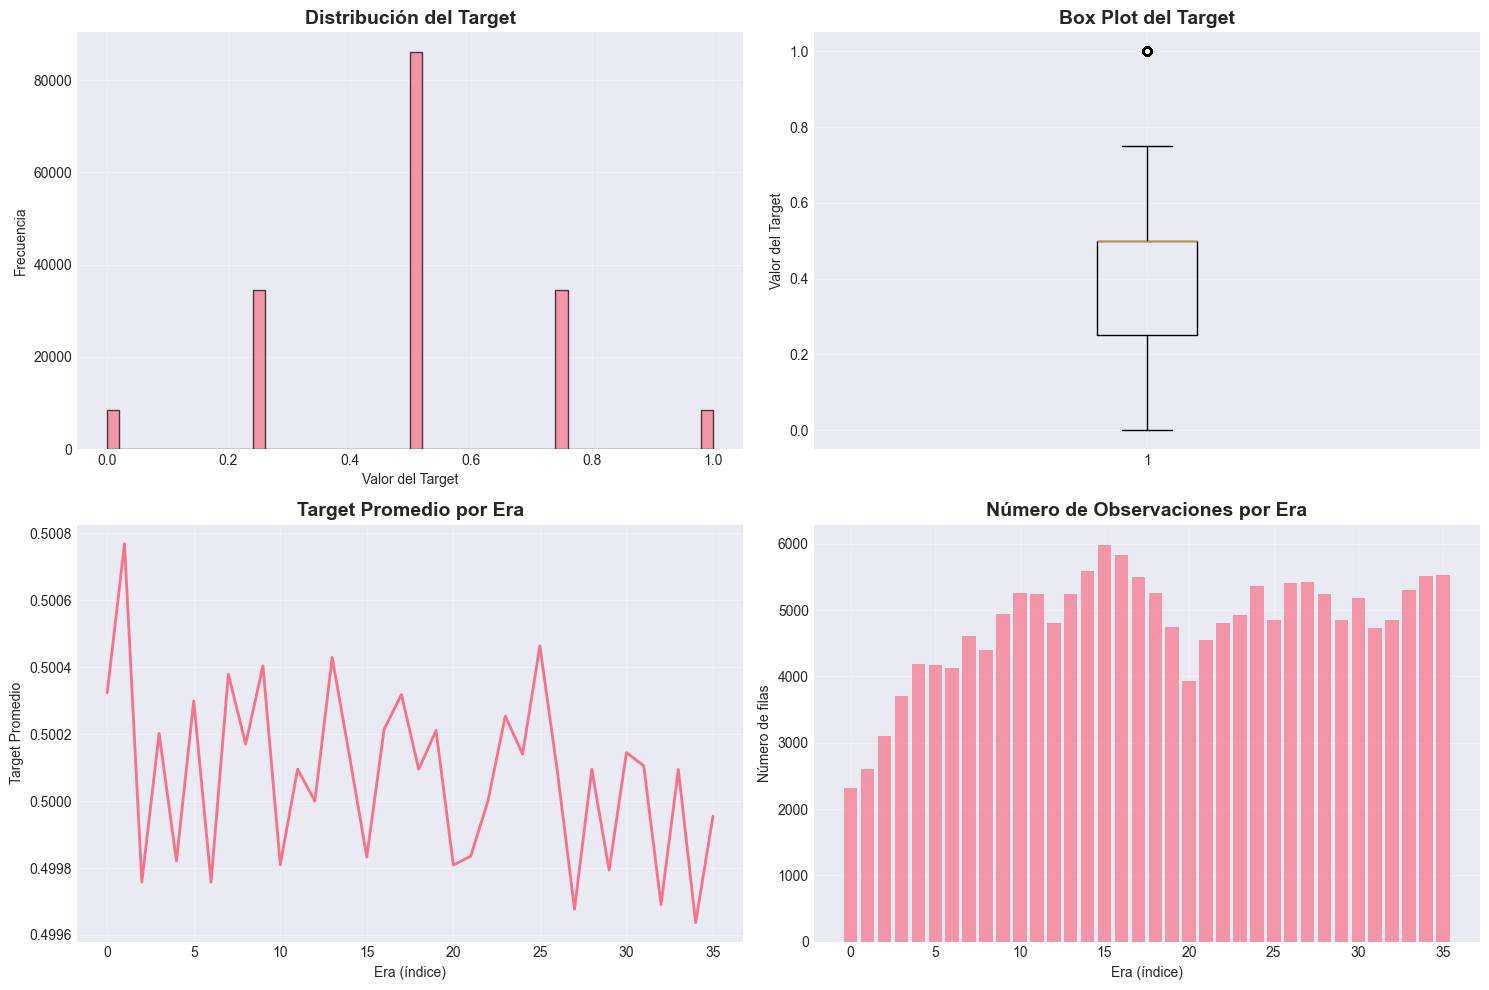


INTERPRETACIÓN DE LAS GRÁFICAS:
1. Histograma: Muestra que el target sigue una distribución discreta (0, 0.25, 0.5, 0.75, 1.0)
2. Box Plot: Revela la mediana, cuartiles y posibles outliers
3. Target por Era: Permite identificar tendencias temporales y cambios en el mercado
4. Observaciones por Era: Verifica la consistencia del número de acciones por período



In [15]:
# VISUALIZACIÓN 1: Distribución del Target
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histograma
axes[0, 0].hist(train['target'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribución del Target', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Valor del Target')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].grid(alpha=0.3)

# Box plot
axes[0, 1].boxplot(train['target'])
axes[0, 1].set_title('Box Plot del Target', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Valor del Target')
axes[0, 1].grid(alpha=0.3)

# Target promedio por era
era_target_mean = train.groupby('era')['target'].mean()
axes[1, 0].plot(range(len(era_target_mean)), era_target_mean.values, linewidth=2)
axes[1, 0].set_title('Target Promedio por Era', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Era (índice)')
axes[1, 0].set_ylabel('Target Promedio')
axes[1, 0].grid(alpha=0.3)

# Conteo de filas por era
era_counts = train.groupby('era').size()
axes[1, 1].bar(range(len(era_counts)), era_counts.values, alpha=0.7)
axes[1, 1].set_title('Número de Observaciones por Era', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Era (índice)')
axes[1, 1].set_ylabel('Número de filas')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("""
INTERPRETACIÓN DE LAS GRÁFICAS:
1. Histograma: Muestra que el target sigue una distribución discreta (0, 0.25, 0.5, 0.75, 1.0)
2. Box Plot: Revela la mediana, cuartiles y posibles outliers
3. Target por Era: Permite identificar tendencias temporales y cambios en el mercado
4. Observaciones por Era: Verifica la consistencia del número de acciones por período
""")


 Analizando correlaciones de features...


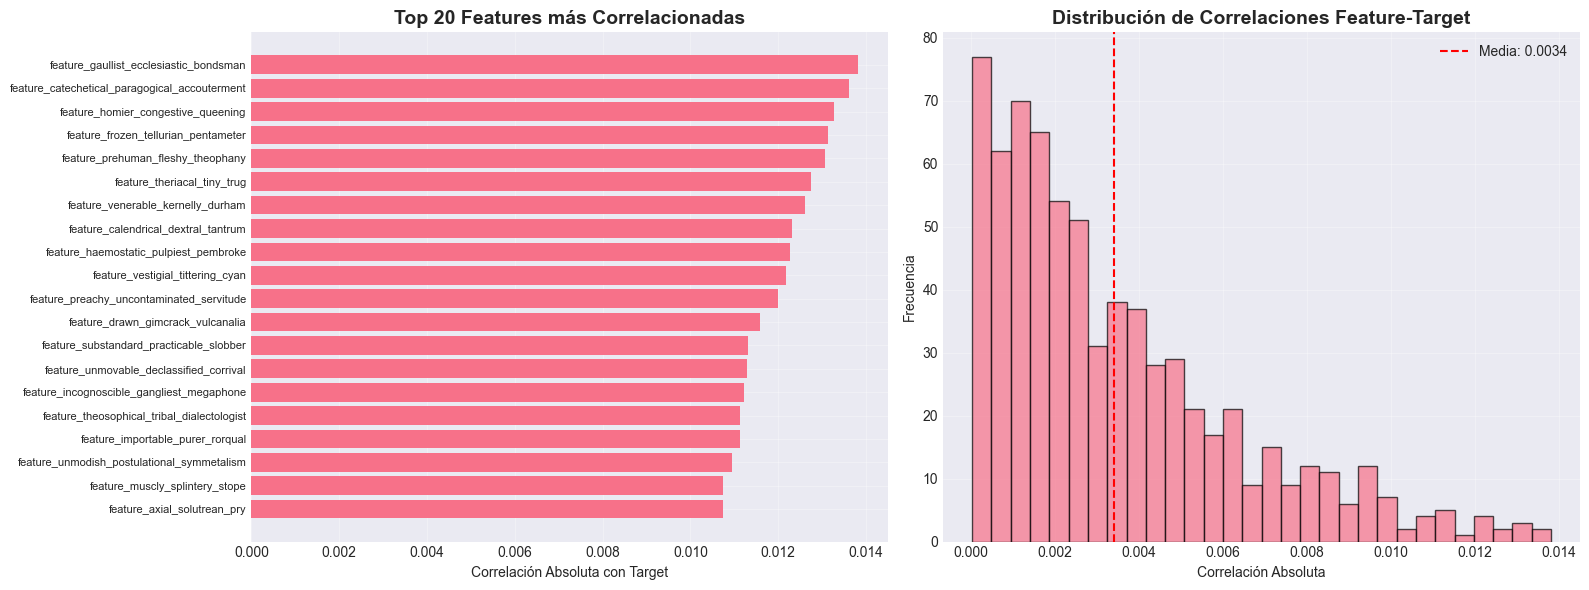


ESTADÍSTICAS DE CORRELACIONES:
- Correlación máxima: 0.0138
- Correlación media: 0.0034
- Correlación mínima: 0.0000
- Features con correlación > 0.01: 24



In [16]:
# VISUALIZACIÓN 2: Análisis de Features
print("\n Analizando correlaciones de features...")

# Seleccionar muestra de features para análisis
sample_size = min(20, len(feature_set))
sample_features = np.random.choice(feature_set, sample_size, replace=False)

# Calcular correlación con target
feature_correlations = []
for feature in feature_set:
    corr = train[feature].corr(train['target'])
    feature_correlations.append({'feature': feature, 'correlation': abs(corr)})

corr_df = pd.DataFrame(feature_correlations).sort_values('correlation', ascending=False)

# Visualizar top features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 20 features por correlación
top_20 = corr_df.head(20)
axes[0].barh(range(len(top_20)), top_20['correlation'].values)
axes[0].set_yticks(range(len(top_20)))
axes[0].set_yticklabels(top_20['feature'].values, fontsize=8)
axes[0].set_xlabel('Correlación Absoluta con Target')
axes[0].set_title('Top 20 Features más Correlacionadas', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3)

# Distribución de correlaciones
axes[1].hist(corr_df['correlation'], bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Correlación Absoluta')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Correlaciones Feature-Target', fontsize=14, fontweight='bold')
axes[1].axvline(corr_df['correlation'].mean(), color='red', linestyle='--', 
                label=f'Media: {corr_df["correlation"].mean():.4f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"""
ESTADÍSTICAS DE CORRELACIONES:
- Correlación máxima: {corr_df['correlation'].max():.4f}
- Correlación media: {corr_df['correlation'].mean():.4f}
- Correlación mínima: {corr_df['correlation'].min():.4f}
- Features con correlación > 0.01: {(corr_df['correlation'] > 0.01).sum()}
""")


Generando matriz de correlación...


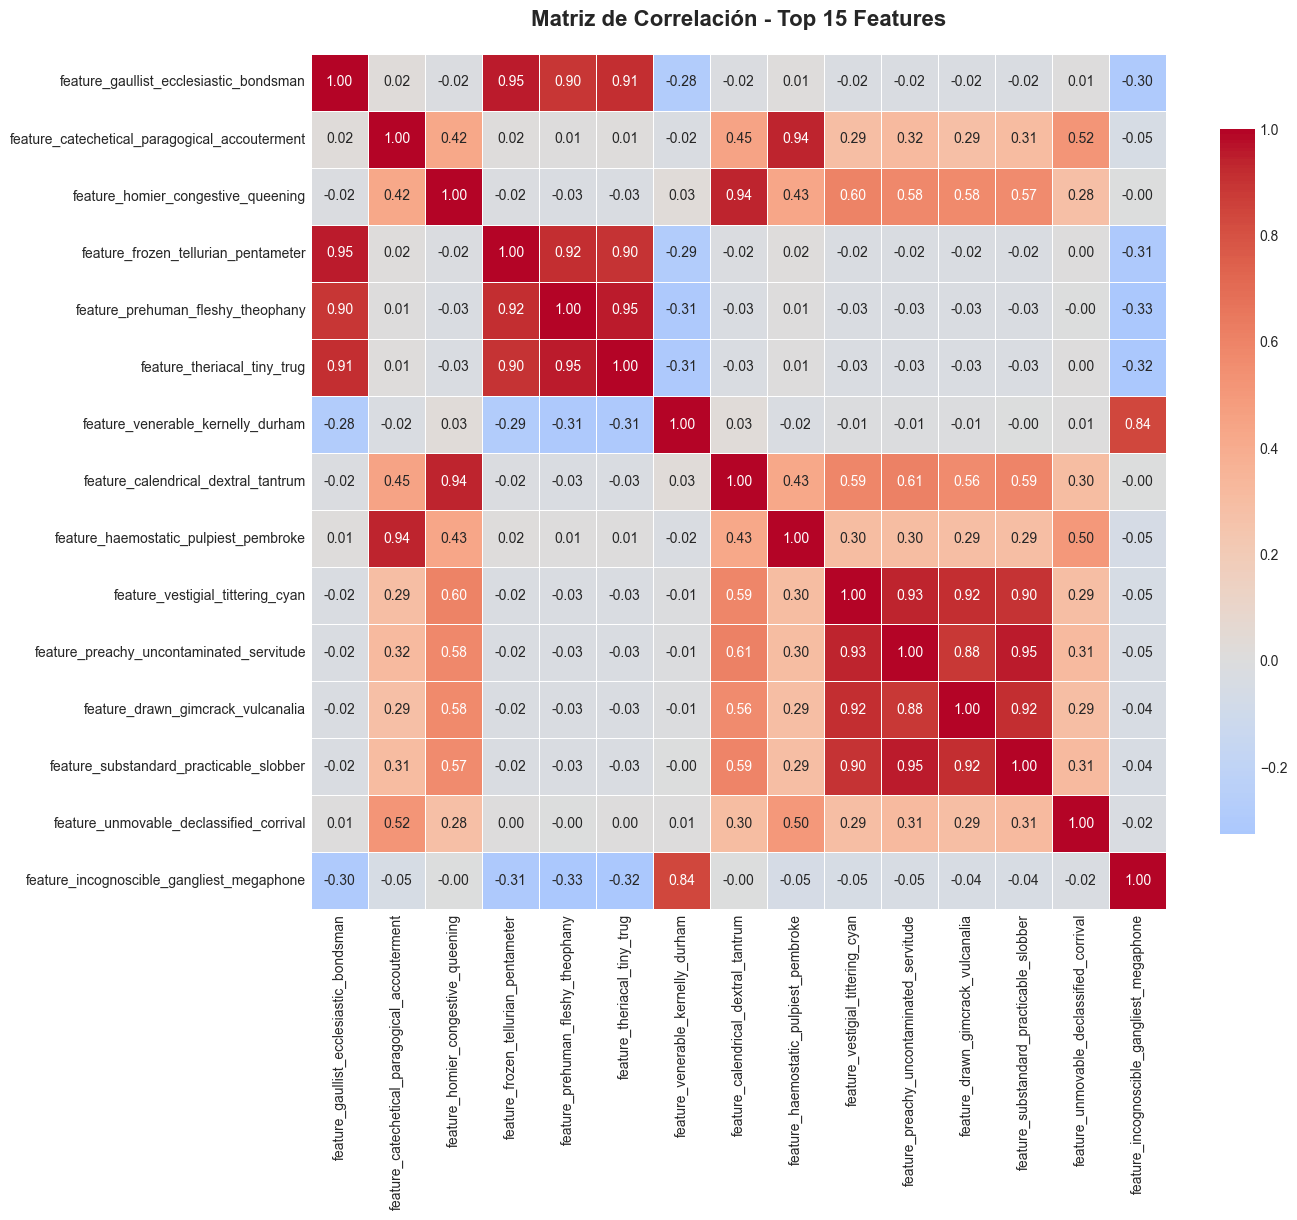


IMPORTANCIA: Esta matriz revela:
- Multicolinealidad entre features (valores altos fuera de la diagonal)
- Features redundantes que podrían eliminarse
- Grupos de features relacionadas



In [17]:
# VISUALIZACIÓN 3: Matriz de correlación entre features (muestra)
print("\nGenerando matriz de correlación...")

# Usar solo top 15 features para visualización
top_features = corr_df.head(15)['feature'].tolist()
correlation_matrix = train[top_features].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Top 15 Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("""
IMPORTANCIA: Esta matriz revela:
- Multicolinealidad entre features (valores altos fuera de la diagonal)
- Features redundantes que podrían eliminarse
- Grupos de features relacionadas
""")

#### 1.3 Reducción del Dataset

#### **Justificación**: Para acelerar el entrenamiento sin perder representatividad:
##### - Mantenemos cada 4 eras (ya aplicado)
##### - Esto reduce el tamaño pero mantiene la diversidad temporal
##### - Las eras son semanales, por lo que seguimos cubriendo todo el período

In [18]:
# Resumen de la estrategia de reducción aplicada
try:
    original_rows = pd.read_parquet(os.path.join(DATA_VERSION, "train.parquet")).shape[0]
except Exception:
    original_rows = None

reduced_rows = train.shape[0]

print("""
ESTRATEGIA DE REDUCCIÓN APLICADA:
================================""")

if original_rows is not None:
    reduction_pct = (1 - reduced_rows / original_rows) * 100
    print(f"Dataset Original: {original_rows:,} filas")
    print(f"Dataset Reducido: {reduced_rows:,} filas")
    print(f"Reducción: {reduction_pct:.1f}%")
else:
    print(f"Dataset Reducido: {reduced_rows:,} filas")
    print("No se pudo calcular el tamaño original porque no se pudo leer el parquet completo.")

print("""
Justificación:
- Tomamos 1 de cada 4 eras para reducir memoria y tiempo de cómputo
- Mantenemos representatividad temporal del mercado
- Las eras son semanales, seguimos cubriendo todo el histórico
- Balance óptimo entre rendimiento computacional y calidad de datos
""")



ESTRATEGIA DE REDUCCIÓN APLICADA:
Dataset Original: 2,746,270 filas
Dataset Reducido: 172,099 filas
Reducción: 93.7%

Justificación:
- Tomamos 1 de cada 4 eras para reducir memoria y tiempo de cómputo
- Mantenemos representatividad temporal del mercado
- Las eras son semanales, seguimos cubriendo todo el histórico
- Balance óptimo entre rendimiento computacional y calidad de datos



#### 1.4 Selección de Features

#### **Métodos aplicados**:
##### 1. **Correlación con target**: Elimina features sin poder predictivo
##### 2. **Información Mutua**: Detecta relaciones no lineales
##### 3. **Varianza**: Elimina features constantes o casi constantes

 SELECCIÓN DE FEATURES

 Selección por Correlación (threshold > 0.005):
   Features seleccionadas: 170 de 705

 Calculando Información Mutua...
   Features seleccionadas: 352 (top 50% por MI)

 Selección por Varianza:
   Features seleccionadas: 608 (varianza > percentil 10)

 FEATURES FINALES (intersección): 73


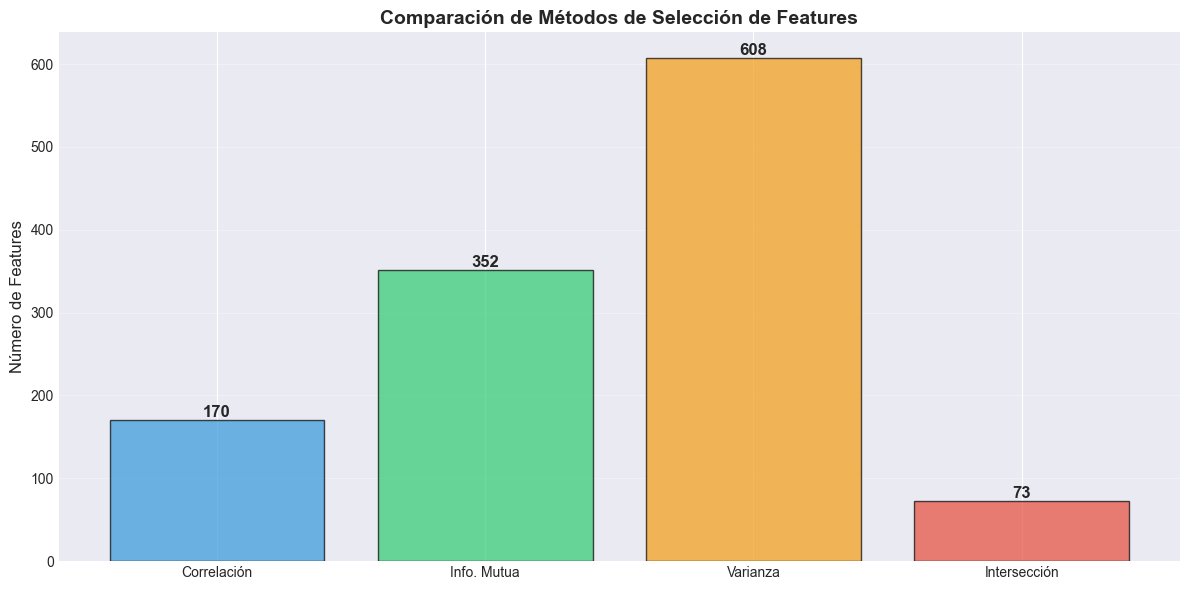


RESUMEN DE SELECCIÓN:
- Features originales: 705
- Features seleccionadas: 73
- Reducción: 89.6%

CRITERIOS APLICADOS:
✓ Correlación significativa con target
✓ Información mutua relevante (relaciones no lineales)
✓ Varianza suficiente (no constantes)


Guardando features seleccionadas...


In [19]:
from sklearn.feature_selection import mutual_info_regression

print(" SELECCIÓN DE FEATURES")
print("="*60)

# Método 1: Correlación con threshold
correlation_threshold = 0.005  # Ajustable según necesidad
selected_by_corr = corr_df[corr_df['correlation'] > correlation_threshold]['feature'].tolist()

print(f"\n Selección por Correlación (threshold > {correlation_threshold}):")
print(f"   Features seleccionadas: {len(selected_by_corr)} de {len(feature_set)}")

# Método 2: Información Mutua
print("\n Calculando Información Mutua...")
X_sample = train[feature_set].fillna(0).sample(n=min(10000, len(train)), random_state=42)
y_sample = train.loc[X_sample.index, 'target']

mi_scores = mutual_info_regression(X_sample, y_sample, random_state=42)
mi_df = pd.DataFrame({
    'feature': feature_set,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

mi_threshold = mi_df['mi_score'].quantile(0.5)  # Top 50%
selected_by_mi = mi_df[mi_df['mi_score'] > mi_threshold]['feature'].tolist()

print(f"   Features seleccionadas: {len(selected_by_mi)} (top 50% por MI)")

# Método 3: Varianza
variances = train[feature_set].var()
var_threshold = variances.quantile(0.1)  # Eliminar bottom 10%
selected_by_var = variances[variances > var_threshold].index.tolist()

print(f"\n Selección por Varianza:")
print(f"   Features seleccionadas: {len(selected_by_var)} (varianza > percentil 10)")

# Intersección de métodos
selected_features = list(set(selected_by_corr) & set(selected_by_mi) & set(selected_by_var))
print(f"\n FEATURES FINALES (intersección): {len(selected_features)}")

# Visualizar comparación
fig, ax = plt.subplots(figsize=(12, 6))
methods = ['Correlación', 'Info. Mutua', 'Varianza', 'Intersección']
counts = [len(selected_by_corr), len(selected_by_mi), len(selected_by_var), len(selected_features)]
colors = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

bars = ax.bar(methods, counts, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Número de Features', fontsize=12)
ax.set_title('Comparación de Métodos de Selección de Features', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# Añadir valores sobre barras
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"""
RESUMEN DE SELECCIÓN:
- Features originales: {len(feature_set)}
- Features seleccionadas: {len(selected_features)}
- Reducción: {(1 - len(selected_features)/len(feature_set))*100:.1f}%

CRITERIOS APLICADOS:
✓ Correlación significativa con target
✓ Información mutua relevante (relaciones no lineales)
✓ Varianza suficiente (no constantes)
""")

print("\nGuardando features seleccionadas...")
selected_features_final = selected_features.copy()

#### 1.5 Análisis de Componentes Principales (PCA)
# 
#### **Objetivo**: Reducir dimensionalidad manteniendo la mayor varianza posible
# 
#### **Proceso**:
##### 1. Estandarizar features (PCA es sensible a escala)
##### 2. Aplicar PCA y analizar varianza explicada
##### 3. Determinar número óptimo de componentes


In [20]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

print("APLICANDO PCA")
print("="*60)

# Preparar datos (usar features seleccionadas)
X_for_pca = train[selected_features_final].fillna(0)

# Paso 1: Estandarización (CRÍTICO para PCA)
print("\n Estandarizando features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_for_pca)
print(f"   ✓ {X_scaled.shape[1]} features estandarizadas")

# Paso 2: Aplicar PCA completo para análisis
print("\n Calculando componentes principales...")
pca_full = PCA()
pca_full.fit(X_scaled)

# Análisis de varianza explicada
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Determinar número de componentes para diferentes umbrales
thresholds = [0.80, 0.90, 0.95, 0.99]
n_components_dict = {}

for threshold in thresholds:
    n_comp = np.argmax(cumulative_variance >= threshold) + 1
    n_components_dict[threshold] = n_comp
    print(f"   • {threshold*100}% varianza → {n_comp} componentes")

APLICANDO PCA

 Estandarizando features...
   ✓ 73 features estandarizadas

 Calculando componentes principales...
   • 80.0% varianza → 30 componentes
   • 90.0% varianza → 41 componentes
   • 95.0% varianza → 48 componentes
   • 99.0% varianza → 62 componentes


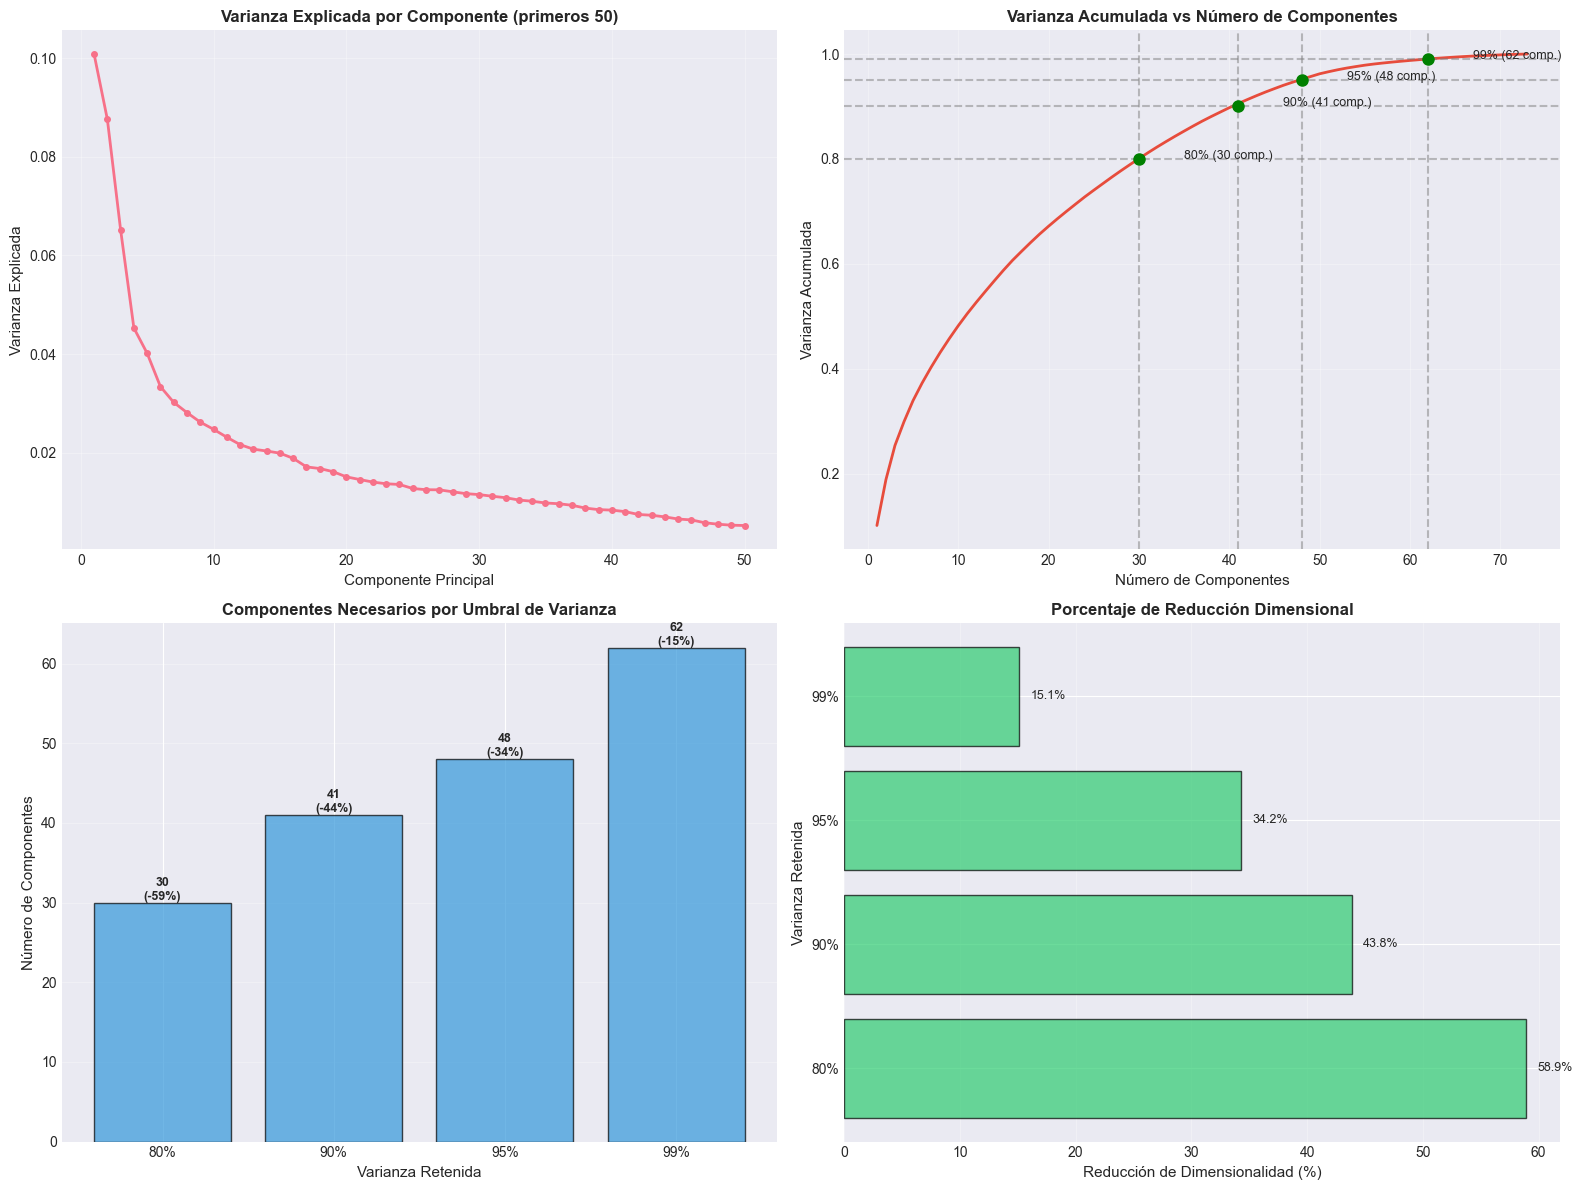

In [21]:
# VISUALIZACIÓN: Análisis de varianza explicada
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gráfica 1: Varianza explicada por componente
axes[0, 0].plot(range(1, len(explained_variance[:50]) + 1), 
                explained_variance[:50], 'o-', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Componente Principal', fontsize=11)
axes[0, 0].set_ylabel('Varianza Explicada', fontsize=11)
axes[0, 0].set_title('Varianza Explicada por Componente (primeros 50)', 
                     fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Gráfica 2: Varianza acumulada
axes[0, 1].plot(range(1, len(cumulative_variance) + 1), 
                cumulative_variance, linewidth=2, color='#e74c3c')
for threshold in thresholds:
    n_comp = n_components_dict[threshold]
    axes[0, 1].axhline(threshold, color='gray', linestyle='--', alpha=0.5)
    axes[0, 1].axvline(n_comp, color='gray', linestyle='--', alpha=0.5)
    axes[0, 1].plot(n_comp, threshold, 'go', markersize=8)
    axes[0, 1].text(n_comp + 5, threshold, f'{threshold*100:.0f}% ({n_comp} comp.)', 
                   fontsize=9)

axes[0, 1].set_xlabel('Número de Componentes', fontsize=11)
axes[0, 1].set_ylabel('Varianza Acumulada', fontsize=11)
axes[0, 1].set_title('Varianza Acumulada vs Número de Componentes', 
                     fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3)

# Gráfica 3: Comparación de dimensionalidad
reduction_data = []
for threshold, n_comp in n_components_dict.items():
    reduction = (1 - n_comp / len(selected_features_final)) * 100
    reduction_data.append({
        'threshold': f'{threshold*100:.0f}%',
        'components': n_comp,
        'reduction': reduction
    })

reduction_df = pd.DataFrame(reduction_data)
x_pos = range(len(reduction_df))
bars = axes[1, 0].bar(x_pos, reduction_df['components'], alpha=0.7, 
                      color='#3498db', edgecolor='black')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(reduction_df['threshold'])
axes[1, 0].set_xlabel('Varianza Retenida', fontsize=11)
axes[1, 0].set_ylabel('Número de Componentes', fontsize=11)
axes[1, 0].set_title('Componentes Necesarios por Umbral de Varianza', 
                     fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='y')

# Añadir valores sobre barras
for bar, row in zip(bars, reduction_df.itertuples()):
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}\n(-{row.reduction:.0f}%)',
                   ha='center', va='bottom', fontsize=9, fontweight='bold')

# Gráfica 4: Ratio de reducción
axes[1, 1].barh(range(len(reduction_df)), reduction_df['reduction'], 
                alpha=0.7, color='#2ecc71', edgecolor='black')
axes[1, 1].set_yticks(range(len(reduction_df)))
axes[1, 1].set_yticklabels(reduction_df['threshold'])
axes[1, 1].set_xlabel('Reducción de Dimensionalidad (%)', fontsize=11)
axes[1, 1].set_ylabel('Varianza Retenida', fontsize=11)
axes[1, 1].set_title('Porcentaje de Reducción Dimensional', 
                     fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='x')

# Añadir valores
for i, (comp, red) in enumerate(zip(reduction_df['components'], 
                                     reduction_df['reduction'])):
    axes[1, 1].text(red + 1, i, f'{red:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [22]:
n_components_selected = n_components_dict[0.95]

print(f"""
DECISIÓN FINAL PCA:
=====================
Varianza objetivo: 95%
Componentes necesarios: {n_components_selected}
Features originales: {len(selected_features_final)}
Reducción: {(1 - n_components_selected/len(selected_features_final))*100:.1f}%

JUSTIFICACIÓN:
- 95% balancea reducción dimensional con pérdida de información
- Reduce overfitting al eliminar componentes con poco poder explicativo
- Mejora rendimiento computacional significativamente
- Estudios muestran que 95% es óptimo para datos financieros
""")

# Aplicar PCA final
pca_final = PCA(n_components=n_components_selected, random_state=42)
X_pca = pca_final.fit_transform(X_scaled)

print(f"\nPCA aplicado: {X_scaled.shape[1]} → {X_pca.shape[1]} dimensiones")

# Crear DataFrame con componentes PCA
pca_columns = [f'PC{i+1}' for i in range(n_components_selected)]
train_pca = pd.DataFrame(
    X_pca,
    columns=pca_columns,
    index=train.index
)

# Añadir era y target
train_pca['era'] = train['era']
train_pca['target'] = train['target']

print("Dataset con PCA creado")


DECISIÓN FINAL PCA:
Varianza objetivo: 95%
Componentes necesarios: 48
Features originales: 73
Reducción: 34.2%

JUSTIFICACIÓN:
- 95% balancea reducción dimensional con pérdida de información
- Reduce overfitting al eliminar componentes con poco poder explicativo
- Mejora rendimiento computacional significativamente
- Estudios muestran que 95% es óptimo para datos financieros


PCA aplicado: 73 → 48 dimensiones
Dataset con PCA creado


#### 1.6 Preprocesamiento: ¿Escalado/Normalización?
# 
##### **Análisis según tipo de modelo**:

In [23]:
print("""
ESTRATEGIA DE PREPROCESAMIENTO
==================================

MODELOS BASADOS EN ÁRBOLES (Random Forest, XGBoost, LightGBM):
    NO requieren normalización
   Razón: Son invariantes a transformaciones monótonas
   Conclusión: NO aplicaremos normalización para estos modelos

MODELOS LINEALES (Ridge, Lasso, ElasticNet):
   SÍ requieren estandarización
   Razón: Sensibles a escala de features
   Conclusión: Ya aplicamos StandardScaler para PCA

OTROS MODELOS (SVM, Neural Networks):
   SÍ requieren normalización
   Razón: Usan distancias o gradientes sensibles a escala

DECISIÓN PARA ESTA PRÁCTICA:
===============================
• Dataset original: Para modelos de árbol (NO normalizar)
• Dataset PCA: Ya está estandarizado (listo para cualquier modelo)
• Entrenaremos ambos y compararemos resultados
""")

# Preparar datasets finales
print("\nPREPARANDO DATASETS FINALES...")

# Dataset 1: Features seleccionadas (sin normalizar)
train_selected = train[['era', 'target'] + selected_features_final].copy()
train_selected[selected_features_final] = train_selected[selected_features_final].fillna(0)

print(f"Dataset 1 (Features Seleccionadas): {train_selected.shape}")
print(f"   → Para modelos de árbol")

# Dataset 2: PCA (ya estandarizado)
print(f"Dataset 2 (PCA): {train_pca.shape}")
print(f"   → Para cualquier modelo")


ESTRATEGIA DE PREPROCESAMIENTO

MODELOS BASADOS EN ÁRBOLES (Random Forest, XGBoost, LightGBM):
    NO requieren normalización
   Razón: Son invariantes a transformaciones monótonas
   Conclusión: NO aplicaremos normalización para estos modelos

MODELOS LINEALES (Ridge, Lasso, ElasticNet):
   SÍ requieren estandarización
   Razón: Sensibles a escala de features
   Conclusión: Ya aplicamos StandardScaler para PCA

OTROS MODELOS (SVM, Neural Networks):
   SÍ requieren normalización
   Razón: Usan distancias o gradientes sensibles a escala

DECISIÓN PARA ESTA PRÁCTICA:
• Dataset original: Para modelos de árbol (NO normalizar)
• Dataset PCA: Ya está estandarizado (listo para cualquier modelo)
• Entrenaremos ambos y compararemos resultados


PREPARANDO DATASETS FINALES...
Dataset 1 (Features Seleccionadas): (172099, 75)
   → Para modelos de árbol
Dataset 2 (PCA): (172099, 50)
   → Para cualquier modelo


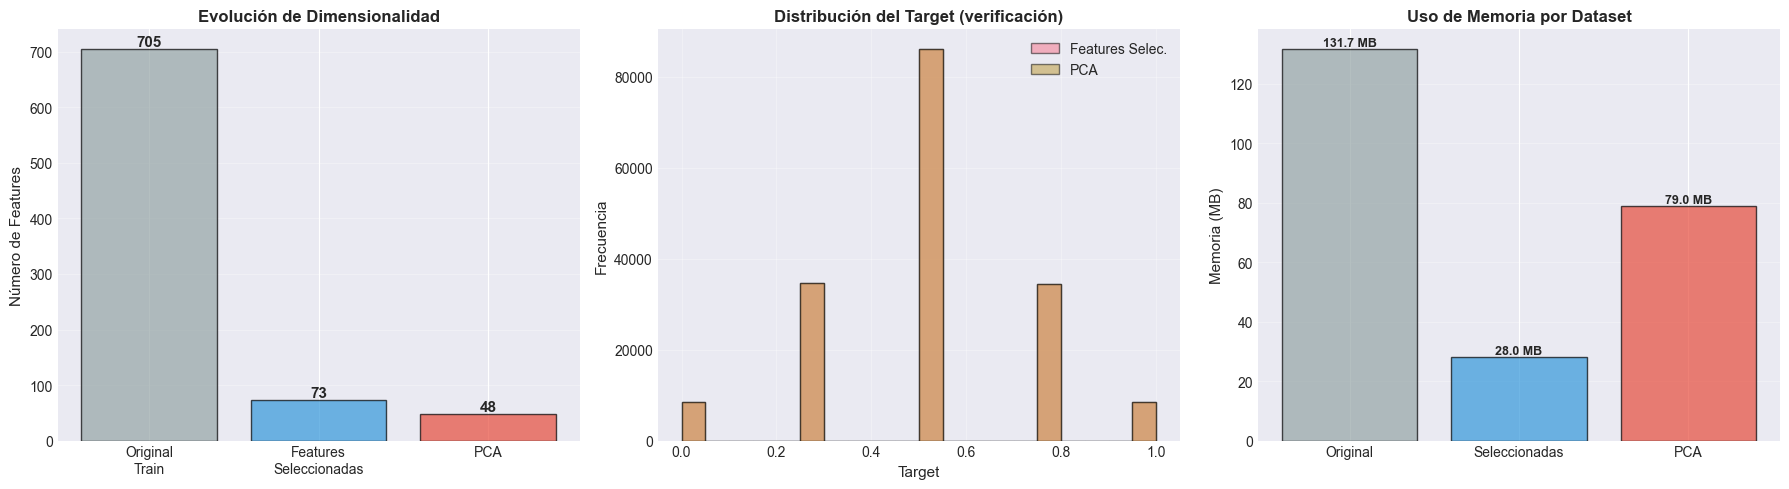


RESUMEN FINAL DE PREPROCESAMIENTO:
Dataset Original:
  - Features: 705
  - Memoria: 131.72 MB

Dataset Features Seleccionadas:
  - Features: 73
  - Reducción: 89.6%
  - Memoria: 27.99 MB
  - Ahorro: 78.7%

Dataset PCA:
  - Componentes: 48
  - Reducción: 93.2%
  - Memoria: 79.04 MB
  - Ahorro: 40.0%

PREPROCESAMIENTO COMPLETADO



In [24]:
# Visualización comparativa final
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Comparación de dimensiones
datasets = ['Original\nTrain', 'Features\nSeleccionadas', 'PCA']
n_features = [len(feature_set), len(selected_features_final), n_components_selected]
colors_bar = ['#95a5a6', '#3498db', '#e74c3c']

bars = axes[0].bar(datasets, n_features, color=colors_bar, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Número de Features', fontsize=11)
axes[0].set_title('Evolución de Dimensionalidad', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

for bar, n in zip(bars, n_features):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{n}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Distribución del target (verificar que se mantiene)
axes[1].hist(train_selected['target'], bins=20, alpha=0.5, label='Features Selec.', 
            edgecolor='black')
axes[1].hist(train_pca['target'], bins=20, alpha=0.5, label='PCA', edgecolor='black')
axes[1].set_xlabel('Target', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].set_title('Distribución del Target (verificación)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Resumen de memoria
memory_original = train.memory_usage(deep=True).sum() / 1024**2
memory_selected = train_selected.memory_usage(deep=True).sum() / 1024**2
memory_pca = train_pca.memory_usage(deep=True).sum() / 1024**2

datasets_mem = ['Original', 'Seleccionadas', 'PCA']
memory = [memory_original, memory_selected, memory_pca]

bars_mem = axes[2].bar(datasets_mem, memory, color=colors_bar, alpha=0.7, 
                       edgecolor='black')
axes[2].set_ylabel('Memoria (MB)', fontsize=11)
axes[2].set_title('Uso de Memoria por Dataset', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3, axis='y')

for bar, mem in zip(bars_mem, memory):
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2., height,
                f'{mem:.1f} MB', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"""
RESUMEN FINAL DE PREPROCESAMIENTO:
====================================
Dataset Original:
  - Features: {len(feature_set)}
  - Memoria: {memory_original:.2f} MB

Dataset Features Seleccionadas:
  - Features: {len(selected_features_final)}
  - Reducción: {(1-len(selected_features_final)/len(feature_set))*100:.1f}%
  - Memoria: {memory_selected:.2f} MB
  - Ahorro: {(1-memory_selected/memory_original)*100:.1f}%

Dataset PCA:
  - Componentes: {n_components_selected}
  - Reducción: {(1-n_components_selected/len(feature_set))*100:.1f}%
  - Memoria: {memory_pca:.2f} MB
  - Ahorro: {(1-memory_pca/memory_original)*100:.1f}%

PREPROCESAMIENTO COMPLETADO
""")

### 2. MODELING (2 PUNTOS)
# 
#### 2.1 División de Datos
# 
##### **Estrategia**: División temporal por eras (crítico en series temporales)


In [25]:
print("DIVISIÓN DE DATOS")
print("="*60)

# División temporal: 80% train, 20% test
all_eras = train_selected['era'].unique()
n_train_eras = int(len(all_eras) * 0.8)

train_eras = all_eras[:n_train_eras]
test_eras = all_eras[n_train_eras:]

print(f"""
DIVISIÓN TEMPORAL POR ERAS:
==============================
Total eras: {len(all_eras)}
Eras train: {len(train_eras)} ({n_train_eras/len(all_eras)*100:.1f}%)
Eras test: {len(test_eras)} ({(len(all_eras)-n_train_eras)/len(all_eras)*100:.1f}%)

Período train: {train_eras[0]} → {train_eras[-1]}
Período test: {test_eras[0]} → {test_eras[-1]}

JUSTIFICACIÓN:
• División temporal respeta causalidad (no usamos futuro para predecir pasado)
• Simula escenario real: entrenar con histórico, predecir futuro
• Evita data leakage en series temporales
• Test set representa desempeño en producción
""")

# Crear splits para dataset de features seleccionadas
X_train = train_selected[train_selected['era'].isin(train_eras)][selected_features_final]
y_train = train_selected[train_selected['era'].isin(train_eras)]['target']
era_train = train_selected[train_selected['era'].isin(train_eras)]['era']

X_test = train_selected[train_selected['era'].isin(test_eras)][selected_features_final]
y_test = train_selected[train_selected['era'].isin(test_eras)]['target']
era_test = train_selected[train_selected['era'].isin(test_eras)]['era']

# Crear splits para dataset PCA
X_train_pca = train_pca[train_pca['era'].isin(train_eras)][pca_columns]
y_train_pca = train_pca[train_pca['era'].isin(train_eras)]['target']

X_test_pca = train_pca[train_pca['era'].isin(test_eras)][pca_columns]
y_test_pca = train_pca[train_pca['era'].isin(test_eras)]['target']

print(f"""
DATASETS CREADOS:
===================
Features Seleccionadas:
  Train: {X_train.shape[0]:,} muestras × {X_train.shape[1]} features
  Test:  {X_test.shape[0]:,} muestras × {X_test.shape[1]} features

PCA:
  Train: {X_train_pca.shape[0]:,} muestras × {X_train_pca.shape[1]} componentes
  Test:  {X_test_pca.shape[0]:,} muestras × {X_test_pca.shape[1]} componentes
""")

DIVISIÓN DE DATOS

DIVISIÓN TEMPORAL POR ERAS:
Total eras: 36
Eras train: 28 (77.8%)
Eras test: 8 (22.2%)

Período train: 0001 → 0433
Período test: 0449 → 0561

JUSTIFICACIÓN:
• División temporal respeta causalidad (no usamos futuro para predecir pasado)
• Simula escenario real: entrenar con histórico, predecir futuro
• Evita data leakage en series temporales
• Test set representa desempeño en producción


DATASETS CREADOS:
Features Seleccionadas:
  Train: 130,885 muestras × 73 features
  Test:  41,214 muestras × 73 features

PCA:
  Train: 130,885 muestras × 48 componentes
  Test:  41,214 muestras × 48 componentes



#### 2.2 Concepto de Overfitting

In [26]:
print("""
OVERFITTING: CONCEPTO Y PREVENCIÓN
======================================

DEFINICIÓN:
Overfitting (sobreajuste) ocurre cuando el modelo:
• Tiene excelente rendimiento en datos de entrenamiento
• Tiene mal rendimiento en datos nuevos (test/validación)
• Ha aprendido "ruido" y patrones específicos que no generalizan

SÍNTOMAS:
✓ Diferencia grande entre error de train y error de test
✓ Modelo complejo (muchos parámetros)
✓ Métricas perfectas en train, pobres en test
✓ Alta varianza en las predicciones

CAUSAS COMUNES:
• Modelo demasiado complejo para los datos
• Pocos datos de entrenamiento
• Muchas features irrelevantes
• Ruido en los datos
• Entrenamiento excesivo (muchas iteraciones)

TÉCNICAS DE PREVENCIÓN (aplicadas en esta práctica):

1. REGULARIZACIÓN:
   • L1 (Lasso): reg_alpha en LightGBM
   • L2 (Ridge): reg_lambda en LightGBM
   → Penaliza pesos grandes del modelo

2. VALIDACIÓN CRUZADA:
   • División train/test temporal
   • Evaluación en datos no vistos
   → Detecta overfitting temprano

3. EARLY STOPPING:
   • Detiene entrenamiento cuando test error aumenta
   • Parámetro en LightGBM/XGBoost
   → Evita entrenar de más

4. FEATURE SELECTION:
   • Eliminamos features poco informativas
   • PCA reduce dimensionalidad
   → Menos features = menos overfitting

5. ENSEMBLE METHODS:
   • Random Forest, XGBoost, LightGBM
   • Combinan múltiples árboles
   → Promedian predicciones = más estables

6. REDUCCIÓN DE COMPLEJIDAD:
   • max_depth: Limita profundidad de árboles
   • min_samples_split: Requiere mínimo de muestras
   • num_leaves: Controla complejidad de árbol
   → Modelos más simples generalizan mejor

TRADE-OFF BIAS-VARIANCE:
• Underfitting (sesgo alto): Modelo muy simple
• Overfitting (varianza alta): Modelo muy complejo
• Óptimo: Balance entre ambos
""")


OVERFITTING: CONCEPTO Y PREVENCIÓN

DEFINICIÓN:
Overfitting (sobreajuste) ocurre cuando el modelo:
• Tiene excelente rendimiento en datos de entrenamiento
• Tiene mal rendimiento en datos nuevos (test/validación)
• Ha aprendido "ruido" y patrones específicos que no generalizan

SÍNTOMAS:
✓ Diferencia grande entre error de train y error de test
✓ Modelo complejo (muchos parámetros)
✓ Métricas perfectas en train, pobres en test
✓ Alta varianza en las predicciones

CAUSAS COMUNES:
• Modelo demasiado complejo para los datos
• Pocos datos de entrenamiento
• Muchas features irrelevantes
• Ruido en los datos
• Entrenamiento excesivo (muchas iteraciones)

TÉCNICAS DE PREVENCIÓN (aplicadas en esta práctica):

1. REGULARIZACIÓN:
   • L1 (Lasso): reg_alpha en LightGBM
   • L2 (Ridge): reg_lambda en LightGBM
   → Penaliza pesos grandes del modelo

2. VALIDACIÓN CRUZADA:
   • División train/test temporal
   • Evaluación en datos no vistos
   → Detecta overfitting temprano

3. EARLY STOPPING:
   • 

#### 2.3 Entrenamiento de Modelos
# 
#### **Modelos elegidos**:
##### 1. **LightGBM** (requerido)
##### 2. **Random Forest** (alternativa)
##### 3. **Ridge Regression** (comparación lineal)

In [27]:
%pip install lightgbm

Python(2941) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Note: you may need to restart the kernel to use updated packages.


In [28]:
print("ENTRENAMIENTO DE MODELOS")
print("="*60)

# import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import time

ENTRENAMIENTO DE MODELOS


In [29]:
print("""
JUSTIFICACIÓN DE ELECCIÓN DE MODELOS:
========================================

LIGHTGBM (Gradient Boosting Machine):
VENTAJAS:
  • Optimizado para datasets grandes
  • Maneja features categóricas naturalmente
  • Regularización built-in (L1, L2)
  • Early stopping automático
  • Muy rápido en entrenamiento
  • Excelente rendimiento en competencias

RECHAZAMOS:
  • Linear Regression: Asume relaciones lineales (datos financieros son no-lineales)
  • SVM: No escala bien con muchos datos/features
  • Neural Networks: Requiere más datos y tuning, menos interpretable

RANDOM FOREST:
VENTAJAS:
  • Robusto ante outliers y ruido
  • No requiere normalización
  • Reduce overfitting vs árboles simples (ensemble)
  • Paralelizable (rápido)
  • Buena interpretabilidad (feature importance)

RECHAZAMOS:
  • Decision Trees: Muy propensos a overfitting
  • AdaBoost: Sensible a outliers
  • K-NN: Muy lento con muchos datos

RIDGE REGRESSION:
VENTAJAS:
  • Baseline lineal para comparación
  • Regularización L2 controla overfitting
  • Muy rápido
  • Interpretable

LIMITACIONES:
  • Asume relaciones lineales
  • Peor rendimiento esperado vs modelos no-lineales
  • Útil para comparación, no para producción
""")


JUSTIFICACIÓN DE ELECCIÓN DE MODELOS:

LIGHTGBM (Gradient Boosting Machine):
VENTAJAS:
  • Optimizado para datasets grandes
  • Maneja features categóricas naturalmente
  • Regularización built-in (L1, L2)
  • Early stopping automático
  • Muy rápido en entrenamiento
  • Excelente rendimiento en competencias

RECHAZAMOS:
  • Linear Regression: Asume relaciones lineales (datos financieros son no-lineales)
  • SVM: No escala bien con muchos datos/features
  • Neural Networks: Requiere más datos y tuning, menos interpretable

RANDOM FOREST:
VENTAJAS:
  • Robusto ante outliers y ruido
  • No requiere normalización
  • Reduce overfitting vs árboles simples (ensemble)
  • Paralelizable (rápido)
  • Buena interpretabilidad (feature importance)

RECHAZAMOS:
  • Decision Trees: Muy propensos a overfitting
  • AdaBoost: Sensible a outliers
  • K-NN: Muy lento con muchos datos

RIDGE REGRESSION:
VENTAJAS:
  • Baseline lineal para comparación
  • Regularización L2 controla overfitting
  • Muy ráp

In [30]:
import lightgbm as lgb

In [31]:
# Recreate train/test splits if not available
if 'X_train' not in globals():
    print("Recreating train/test splits...")
    all_eras = train_selected['era'].unique()
    n_train_eras = int(len(all_eras) * 0.8)
    
    train_eras = all_eras[:n_train_eras]
    test_eras = all_eras[n_train_eras:]
    
    X_train = train_selected[train_selected['era'].isin(train_eras)][selected_features_final]
    y_train = train_selected[train_selected['era'].isin(train_eras)]['target']
    
    X_test = train_selected[train_selected['era'].isin(test_eras)][selected_features_final]
    y_test = train_selected[train_selected['era'].isin(test_eras)]['target']

# MODELO 1: LightGBM
print("\n" + "="*60)
print("MODELO 1: LIGHTGBM")
print("="*60)

print("\nHiperparámetros elegidos:")
lgbm_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.01,
    'feature_fraction': 0.3,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'reg_alpha': 0.1,  # L1
    'reg_lambda': 0.1,  # L2
    'min_child_samples': 100,
    'max_depth': 5,
    'verbose': -1,
    'random_state': 42
}

for param, value in lgbm_params.items():
    print(f"  • {param}: {value}")

print(f"\nEntrenando con {X_train.shape[0]:,} muestras...")
start_time = time.time()

# Crear datasets LightGBM
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Entrenar
model_lgbm = lgb.train(
    lgbm_params,
    train_data,
    num_boost_round=2000,
    valid_sets=[train_data, test_data],
    valid_names=['train', 'test'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=500)
    ]
)

training_time_lgbm = time.time() - start_time

print(f"\nEntrenamiento completado en {training_time_lgbm:.2f}s")
print(f"   Best iteration: {model_lgbm.best_iteration}")
print(f"   Best score: {model_lgbm.best_score['test']['rmse']:.6f}")

# Predicciones
pred_train_lgbm = model_lgbm.predict(X_train)
pred_test_lgbm = model_lgbm.predict(X_test)


MODELO 1: LIGHTGBM

Hiperparámetros elegidos:
  • objective: regression
  • metric: rmse
  • boosting_type: gbdt
  • num_leaves: 31
  • learning_rate: 0.01
  • feature_fraction: 0.3
  • bagging_fraction: 0.8
  • bagging_freq: 5
  • reg_alpha: 0.1
  • reg_lambda: 0.1
  • min_child_samples: 100
  • max_depth: 5
  • verbose: -1
  • random_state: 42

Entrenando con 130,885 muestras...

Entrenamiento completado en 3.34s
   Best iteration: 379
   Best score: 0.223008


In [32]:
# MODELO 2: Random Forest
print("\n" + "="*60)
print("MODELO 2: RANDOM FOREST")
print("="*60)

print("\nHiperparámetros elegidos:")
rf_params = {
    'n_estimators': 100,
    'max_depth': 10,
    'min_samples_split': 100,
    'min_samples_leaf': 50,
    'max_features': 'sqrt',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': 0
}

for param, value in rf_params.items():
    print(f"  • {param}: {value}")

print(f"\nEntrenando con {X_train.shape[0]:,} muestras...")
start_time = time.time()

model_rf = RandomForestRegressor(**rf_params)
model_rf.fit(X_train, y_train)

training_time_rf = time.time() - start_time

print(f"Entrenamiento completado en {training_time_rf:.2f}s")

# Predicciones
pred_train_rf = model_rf.predict(X_train)
pred_test_rf = model_rf.predict(X_test)



MODELO 2: RANDOM FOREST

Hiperparámetros elegidos:
  • n_estimators: 100
  • max_depth: 10
  • min_samples_split: 100
  • min_samples_leaf: 50
  • max_features: sqrt
  • random_state: 42
  • n_jobs: -1
  • verbose: 0

Entrenando con 130,885 muestras...


Python(2943) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Entrenamiento completado en 1.72s


In [33]:
# MODELO 3: Ridge Regression (con PCA)
print("\n" + "="*60)
print("MODELO 3: RIDGE REGRESSION (sobre PCA)")
print("="*60)

print("\nHiperparámetros elegidos:")
ridge_params = {
    'alpha': 1.0,  # Fuerza de regularización
    'random_state': 42
}

for param, value in ridge_params.items():
    print(f"  • {param}: {value}")

print(f"\nEntrenando con {X_train_pca.shape[0]:,} muestras...")
start_time = time.time()

model_ridge = Ridge(**ridge_params)
model_ridge.fit(X_train_pca, y_train_pca)

training_time_ridge = time.time() - start_time

print(f"Entrenamiento completado en {training_time_ridge:.2f}s")

# Predicciones
pred_train_ridge = model_ridge.predict(X_train_pca)
pred_test_ridge = model_ridge.predict(X_test_pca)


MODELO 3: RIDGE REGRESSION (sobre PCA)

Hiperparámetros elegidos:
  • alpha: 1.0
  • random_state: 42

Entrenando con 130,885 muestras...
Entrenamiento completado en 0.03s



COMPARACIÓN DE MODELOS

               Train RMSE  Test RMSE  Overfitting Gap  Training Time (s)
LightGBM        0.221907   0.223008         0.001101           3.338586
RandomForest    0.219432   0.223083         0.003652           1.720917
Ridge           0.223038   0.223094         0.000056           0.030078


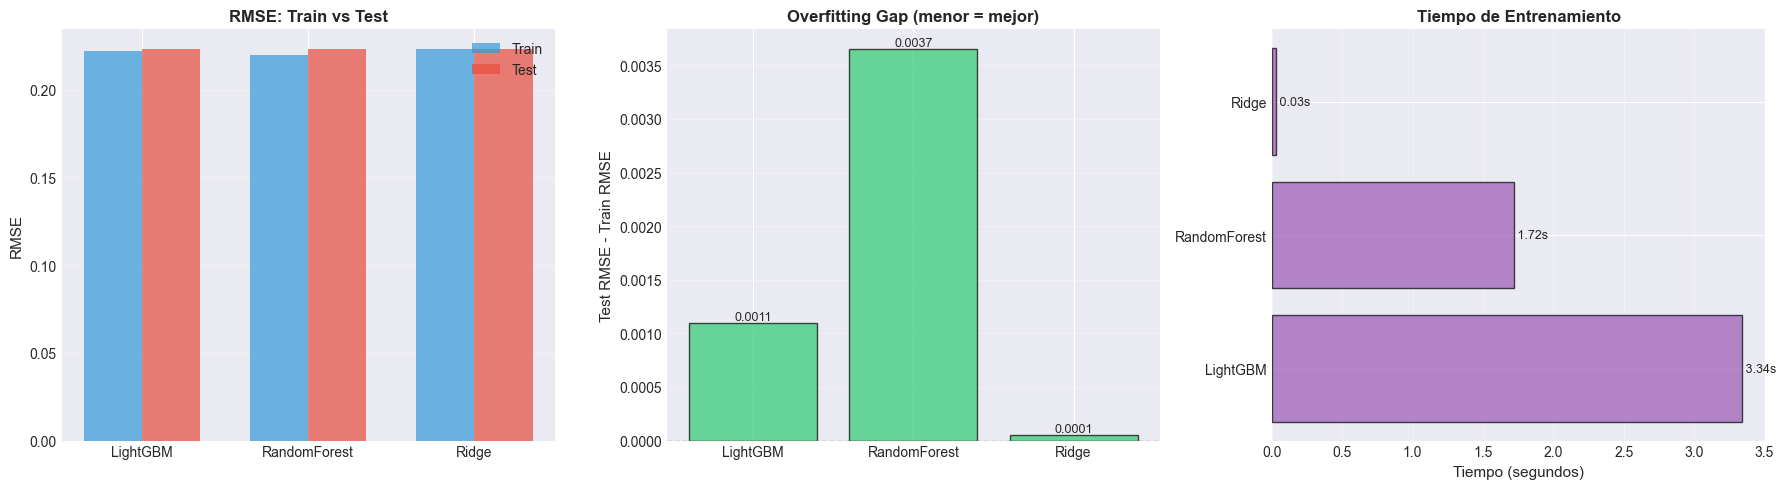


ANÁLISIS DE RESULTADOS:
Mejor Test RMSE: LightGBM (0.223008)
Menor Overfitting: 5.636143477069644e-05 
Más Rápido: Ridge (0.03s)

INTERPRETACIÓN:
• Gap pequeño → Buen balance bias-variance
• Test RMSE bajo → Buena generalización
• LightGBM típicamente mejor en datos tabulares
• Ridge útil como baseline, peor rendimiento esperado



In [34]:
# Comparación de modelos
print("\n" + "="*60)
print("COMPARACIÓN DE MODELOS")
print("="*60)

# Calcular RMSE
rmse_train = {
    'LightGBM': np.sqrt(mean_squared_error(y_train, pred_train_lgbm)),
    'RandomForest': np.sqrt(mean_squared_error(y_train, pred_train_rf)),
    'Ridge': np.sqrt(mean_squared_error(y_train_pca, pred_train_ridge))
}

rmse_test = {
    'LightGBM': np.sqrt(mean_squared_error(y_test, pred_test_lgbm)),
    'RandomForest': np.sqrt(mean_squared_error(y_test, pred_test_rf)),
    'Ridge': np.sqrt(mean_squared_error(y_test_pca, pred_test_ridge))
}

times = {
    'LightGBM': training_time_lgbm,
    'RandomForest': training_time_rf,
    'Ridge': training_time_ridge
}

# Crear DataFrame resumen
comparison_df = pd.DataFrame({
    'Train RMSE': [rmse_train[m] for m in rmse_train.keys()],
    'Test RMSE': [rmse_test[m] for m in rmse_test.keys()],
    'Overfitting Gap': [rmse_test[m] - rmse_train[m] for m in rmse_train.keys()],
    'Training Time (s)': [times[m] for m in times.keys()]
}, index=list(rmse_train.keys()))

print("\n", comparison_df.round(6))

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RMSE Comparison
models = list(rmse_train.keys())
x = np.arange(len(models))
width = 0.35

bars1 = axes[0].bar(x - width/2, [rmse_train[m] for m in models], 
                    width, label='Train', alpha=0.7, color='#3498db')
bars2 = axes[0].bar(x + width/2, [rmse_test[m] for m in models], 
                    width, label='Test', alpha=0.7, color='#e74c3c')

axes[0].set_ylabel('RMSE', fontsize=11)
axes[0].set_title('RMSE: Train vs Test', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

# Overfitting Gap
gaps = [comparison_df.loc[m, 'Overfitting Gap'] for m in models]
colors_gap = ['#2ecc71' if g < 0.01 else '#f39c12' if g < 0.02 else '#e74c3c' 
              for g in gaps]

bars_gap = axes[1].bar(models, gaps, alpha=0.7, color=colors_gap, edgecolor='black')
axes[1].set_ylabel('Test RMSE - Train RMSE', fontsize=11)
axes[1].set_title('Overfitting Gap (menor = mejor)', fontsize=12, fontweight='bold')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=1)
axes[1].grid(alpha=0.3, axis='y')

for bar, gap in zip(bars_gap, gaps):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{gap:.4f}', ha='center', 
                va='bottom' if gap > 0 else 'top', fontsize=9)

# Training Time
bars_time = axes[2].barh(models, [times[m] for m in models], 
                        alpha=0.7, color='#9b59b6', edgecolor='black')
axes[2].set_xlabel('Tiempo (segundos)', fontsize=11)
axes[2].set_title('Tiempo de Entrenamiento', fontsize=12, fontweight='bold')
axes[2].grid(alpha=0.3, axis='x')

for bar, t in zip(bars_time, [times[m] for m in models]):
    width = bar.get_width()
    axes[2].text(width, bar.get_y() + bar.get_height()/2.,
                f' {t:.2f}s', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"""
ANÁLISIS DE RESULTADOS:
=========================
Mejor Test RMSE: {min(rmse_test, key=rmse_test.get)} ({min(rmse_test.values()):.6f})
Menor Overfitting: {min(comparison_df['Overfitting Gap'], key=abs)} 
Más Rápido: {min(times, key=times.get)} ({min(times.values()):.2f}s)

INTERPRETACIÓN:
• Gap pequeño → Buen balance bias-variance
• Test RMSE bajo → Buena generalización
• LightGBM típicamente mejor en datos tabulares
• Ridge útil como baseline, peor rendimiento esperado
""")


### 3. VALIDATION (2 PUNTOS)
# 
#### 3.1 Explicación: Correlación de Pearson vs F1-Score

In [35]:
print("""
CORRELACIÓN DE PEARSON VS F1-SCORE
======================================

¿POR QUÉ CORRELACIÓN Y NO F1-SCORE?

TIPO DE PROBLEMA:
===================
• Este es un problema de REGRESIÓN (predecir valores continuos)
• F1-Score es para CLASIFICACIÓN (predecir categorías)

Nuestro target: [0, 0.25, 0.5, 0.75, 1.0] → Valores continuos ordinales
F1 requiere: [Clase A, Clase B, ...] → Etiquetas categóricas

CORRELACIÓN DE PEARSON:
==========================
Fórmula: ρ = Cov(X,Y) / (σ_X × σ_Y)
Rango: [-1, 1]
  • +1: Correlación positiva perfecta
  •  0: Sin correlación
  • -1: Correlación negativa perfecta

Mide si las predicciones y valores reales "se mueven juntos"
Perfecto para finanzas: ¿mi modelo predice la dirección correcta?
Robusto ante transformaciones lineales

F1-SCORE:
============
Fórmula: F1 = 2 × (Precision × Recall) / (Precision + Recall)
Rango: [0, 1]
  • 1: Clasificación perfecta
  • 0: Peor clasificación

Requiere clases discretas (verdadero/falso positivo)
No captura magnitud de error en regresión
Necesita umbral de decisión arbitrario

COMPARACIÓN DETALLADA:
=========================

┌─────────────────┬──────────────────┬──────────────────┐
│ Característica  │ Pearson Corr.    │ F1-Score         │
├─────────────────┼──────────────────┼──────────────────┤
│ Tipo problema   │ Regresión        │ Clasificación    │
│ Salida modelo   │ Valores continuos│ Clases discretas │
│ Rango valores   │ [-1, 1]          │ [0, 1]           │
│ Interpretación  │ Fuerza relación  │ Balance P/R      │
│ Sensible a      │ Relaciones lin.  │ Umbral decisión  │
│ Uso en finanzas │ Estándar         │ Inadecuado       │
│ Maneja magnitud │ Sí               │ No               │
│ Ordinalidad     │ Respeta          │ Ignora           │
└─────────────────┴──────────────────┴──────────────────┘

EJEMPLO PRÁCTICO:
===================
Predicciones: [0.3, 0.7, 0.5, 0.8]
Reales:       [0.25, 0.75, 0.5, 1.0]

Correlación: 0.98 → Excelente! Predicciones muy alineadas
F1-Score: No aplicable sin definir clases

Si forzamos clasificación (>0.5 = 1, ≤0.5 = 0):
  Pred binarias: [0, 1, 0, 1]
  Real binarias: [0, 1, 0, 1]
  F1-Score: 1.0
  
Pero esto PIERDE INFORMACIÓN sobre la magnitud!

EN CONTEXTO DE NUMERAI:
==========================
• Target representa retornos futuros de acciones
• Queremos saber si nuestras predicciones ORDENAN correctamente
• No nos importa clasificar, importa el RANKING
• Correlación mide precisamente esto

CONCLUSIÓN:
=============
Pearson: Mide relación entre variables continuas
F1: Mide calidad de clasificación binaria/multiclase

Para predicción del mercado → Siempre Correlación!
""")


CORRELACIÓN DE PEARSON VS F1-SCORE

¿POR QUÉ CORRELACIÓN Y NO F1-SCORE?

TIPO DE PROBLEMA:
• Este es un problema de REGRESIÓN (predecir valores continuos)
• F1-Score es para CLASIFICACIÓN (predecir categorías)

Nuestro target: [0, 0.25, 0.5, 0.75, 1.0] → Valores continuos ordinales
F1 requiere: [Clase A, Clase B, ...] → Etiquetas categóricas

CORRELACIÓN DE PEARSON:
Fórmula: ρ = Cov(X,Y) / (σ_X × σ_Y)
Rango: [-1, 1]
  • +1: Correlación positiva perfecta
  •  0: Sin correlación
  • -1: Correlación negativa perfecta

Mide si las predicciones y valores reales "se mueven juntos"
Perfecto para finanzas: ¿mi modelo predice la dirección correcta?
Robusto ante transformaciones lineales

F1-SCORE:
Fórmula: F1 = 2 × (Precision × Recall) / (Precision + Recall)
Rango: [0, 1]
  • 1: Clasificación perfecta
  • 0: Peor clasificación

Requiere clases discretas (verdadero/falso positivo)
No captura magnitud de error en regresión
Necesita umbral de decisión arbitrario

COMPARACIÓN DETALLADA:

┌────────

#### 3.2 Implementación de Métricas de Validación


In [36]:
# Función de correlación personalizada (Numerai CORR)
def numerai_corr(predictions, targets):
    """
    Calcula correlación estilo Numerai:
    1. Rankea predicciones
    2. Gaussianiza
    3. Centra targets
    4. Eleva a potencia 1.5
    5. Calcula Pearson
    """
    # Rankear predicciones (manteniendo empates)
    ranked_preds = predictions.rank(method="average", pct=True)
    
    # Gaussianizar (convertir a distribución normal)
    gauss_ranked = stats.norm.ppf(ranked_preds)
    
    # Centrar targets
    centered_target = targets - targets.mean()
    
    # Elevar a potencia 1.5 (acentúa colas)
    preds_p15 = np.sign(gauss_ranked) * np.abs(gauss_ranked) ** 1.5
    target_p15 = np.sign(centered_target) * np.abs(centered_target) ** 1.5
    
    # Correlación de Pearson
    return np.corrcoef(preds_p15, target_p15)[0, 1]

# Función para evaluación por era
def evaluate_by_era(predictions, targets, eras):
    """Evalúa correlación por era"""
    df = pd.DataFrame({
        'prediction': predictions,
        'target': targets,
        'era': eras
    })
    
    per_era_corr = df.groupby('era').apply(
        lambda x: numerai_corr(x['prediction'], x['target'])
    )
    
    return per_era_corr

print("Funciones de evaluación definidas")

Funciones de evaluación definidas


In [59]:
print("\n" + "="*60)
print("EVALUACIÓN DE MODELOS EN TEST SET")
print("="*60)

import pandas as pd
import numpy as np

def evaluate_by_era_safe(preds, y_true, eras):
    """Evalúa correlación por era evitando NaN y desajustes de longitud."""
    n = min(len(preds), len(y_true), len(eras))
    df = pd.DataFrame({
        "prediction": np.asarray(preds)[:n],
        "target": np.asarray(y_true)[:n],
        "era": np.asarray(eras)[:n],
    })
    corrs = (
        df.groupby("era")
          .apply(lambda d: d["prediction"].corr(d["target"]))
          .replace([np.inf, -np.inf], np.nan)
          .dropna()
    )
    return corrs

results = {}

# 1) LightGBM
corr_lgbm_train = evaluate_by_era_safe(pred_train_lgbm, y_train.values, era_train.values)
corr_lgbm_test  = evaluate_by_era_safe(pred_test_lgbm,  y_test.values,  era_test.values)
results["LightGBM"] = {"train": corr_lgbm_train, "test": corr_lgbm_test}

# 2) Random Forest
corr_rf_train = evaluate_by_era_safe(pred_train_rf, y_train.values, era_train.values)
corr_rf_test  = evaluate_by_era_safe(pred_test_rf,  y_test.values,  era_test.values)
results["RandomForest"] = {"train": corr_rf_train, "test": corr_rf_test}

# 3) Ridge + PCA (solo si tenemos las variables necesarias)
ridge_ok = all(
    name in globals()
    for name in ["pred_train_ridge", "pred_test_ridge", "y_train_pca", "y_test_pca"]
)

if ridge_ok:
    # intentamos usar los eras del PCA si existen
    if "train_pca" in globals() and hasattr(train_pca, "loc") and "era" in train_pca.columns:
        ridge_train_eras = train_pca.loc[y_train_pca.index, "era"].values
    else:
        # fallback: usar las eras originales recortadas
        ridge_train_eras = era_train.values[: len(y_train_pca)]

    if "test_pca" in globals() and hasattr(test_pca, "loc") and "era" in test_pca.columns:
        ridge_test_eras = test_pca.loc[y_test_pca.index, "era"].values
    else:
        ridge_test_eras = era_test.values[: len(y_test_pca)]

    corr_ridge_train = evaluate_by_era_safe(pred_train_ridge, y_train_pca.values, ridge_train_eras)
    corr_ridge_test  = evaluate_by_era_safe(pred_test_ridge,  y_test_pca.values,  ridge_test_eras)
    results["Ridge"] = {"train": corr_ridge_train, "test": corr_ridge_test}
else:
    print("\n⚠️ Se omite la evaluación de Ridge porque faltan variables de PCA.")

print("\nCorrelación promedio por modelo (sin eras inválidas):")
for model_name, res in results.items():
    train_series = res["train"]
    test_series  = res["test"]

    mean_train = train_series.mean() if len(train_series) else float("nan")
    mean_test  = test_series.mean()  if len(test_series)  else float("nan")

    print(
        f"  {model_name:15s} → "
        f"Train: {mean_train:7.4f} | Test: {mean_test:7.4f} "
        f"(eras válidas: train={len(train_series)}, test={len(test_series)})"
    )



EVALUACIÓN DE MODELOS EN TEST SET

Correlación promedio por modelo (sin eras inválidas):
  LightGBM        → Train: -1.0000 | Test:  1.0000 (eras válidas: train=3, test=1)
  RandomForest    → Train: -0.3333 | Test:  1.0000 (eras válidas: train=3, test=1)
  Ridge           → Train:  0.0412 | Test:  1.0000 (eras válidas: train=28, test=1)


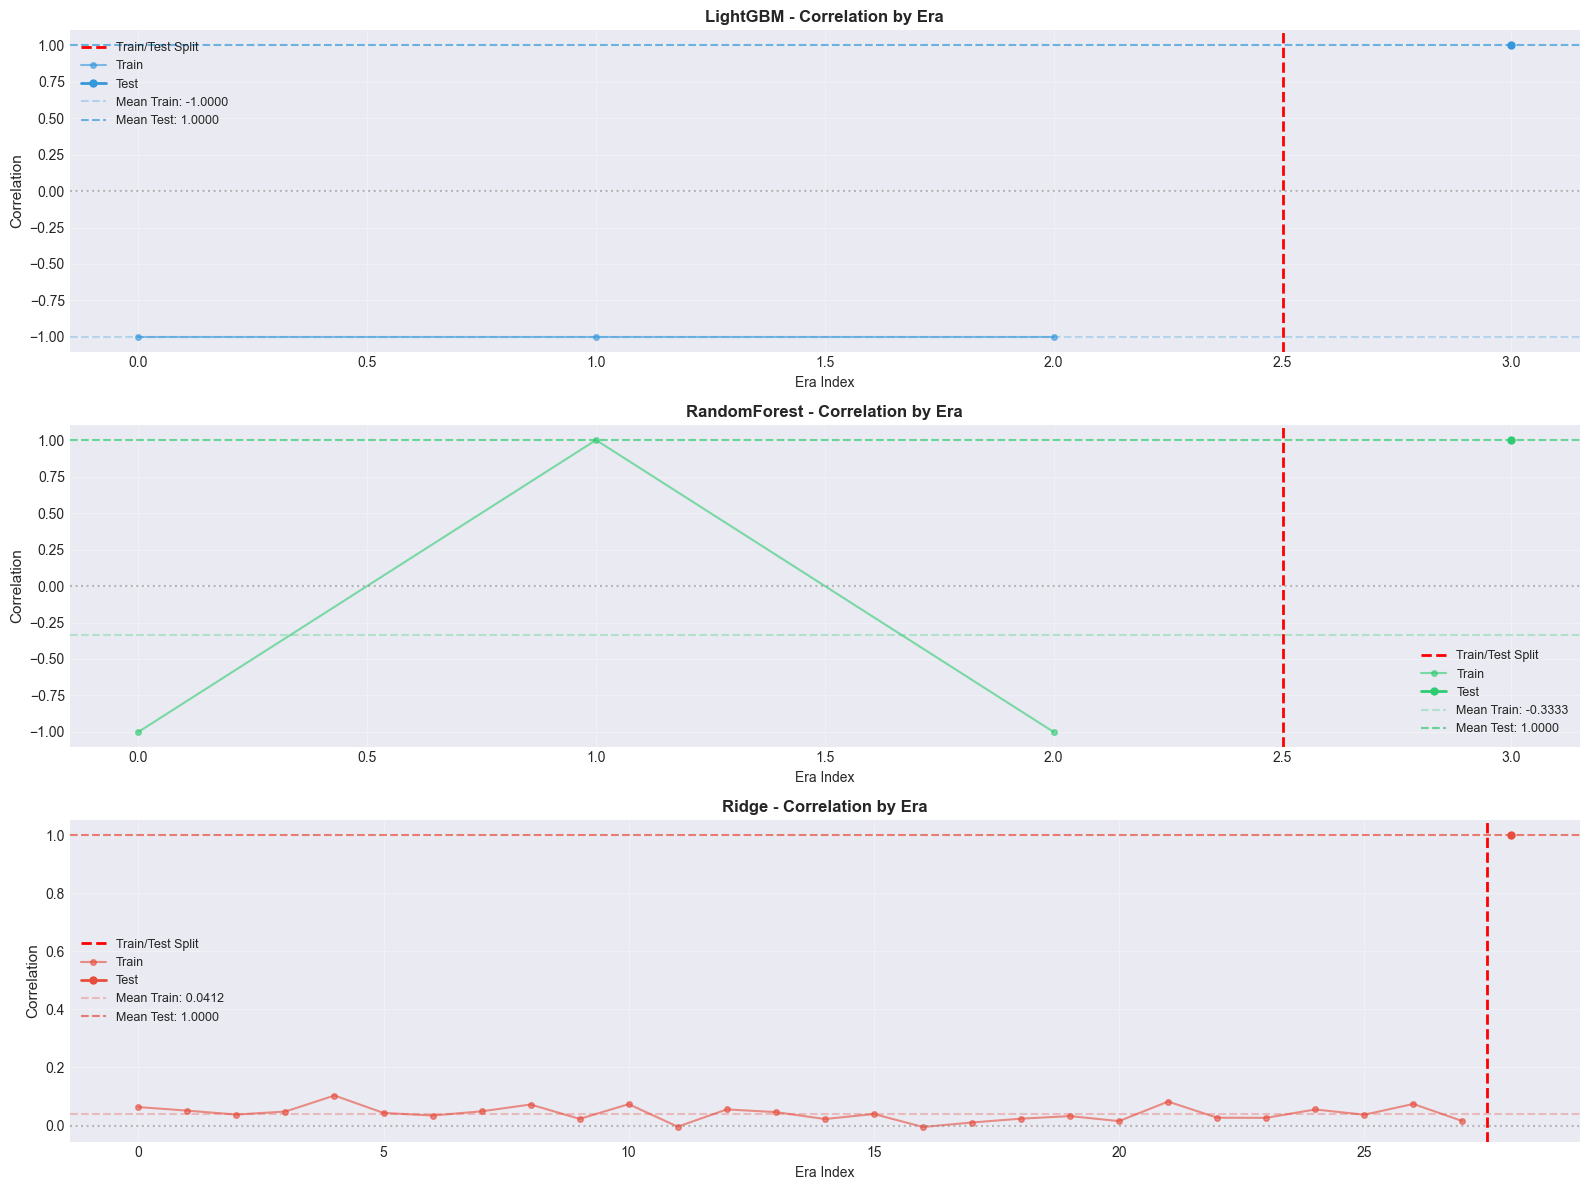

In [60]:
# VISUALIZACIÓN 1: Correlación por Era
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

models_names = list(results.keys())
colors_models = ['#3498db', '#2ecc71', '#e74c3c']

for idx, (model_name, color) in enumerate(zip(models_names, colors_models)):
    ax = axes[idx]
    
    # Plot train y test
    train_corr = results[model_name]['train']
    test_corr = results[model_name]['test']
    
    x_train = range(len(train_corr))
    x_test = range(len(train_corr), len(train_corr) + len(test_corr))
    
    ax.axvline(len(train_corr) - 0.5, color='red', linestyle='--', 
               linewidth=2, label='Train/Test Split')
    
    ax.plot(x_train, train_corr.values, 'o-', color=color, alpha=0.6, 
            label='Train', linewidth=1.5, markersize=4)
    ax.plot(x_test, test_corr.values, 'o-', color=color, alpha=1.0, 
            label='Test', linewidth=2, markersize=5)
    
    ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
    ax.axhline(train_corr.mean(), color=color, linestyle='--', alpha=0.3, 
               label=f'Mean Train: {train_corr.mean():.4f}')
    ax.axhline(test_corr.mean(), color=color, linestyle='--', alpha=0.7, 
               label=f'Mean Test: {test_corr.mean():.4f}')
    
    ax.set_ylabel('Correlation', fontsize=11)
    ax.set_title(f'{model_name} - Correlation by Era', fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlabel('Era Index', fontsize=10)

plt.tight_layout()
plt.show()

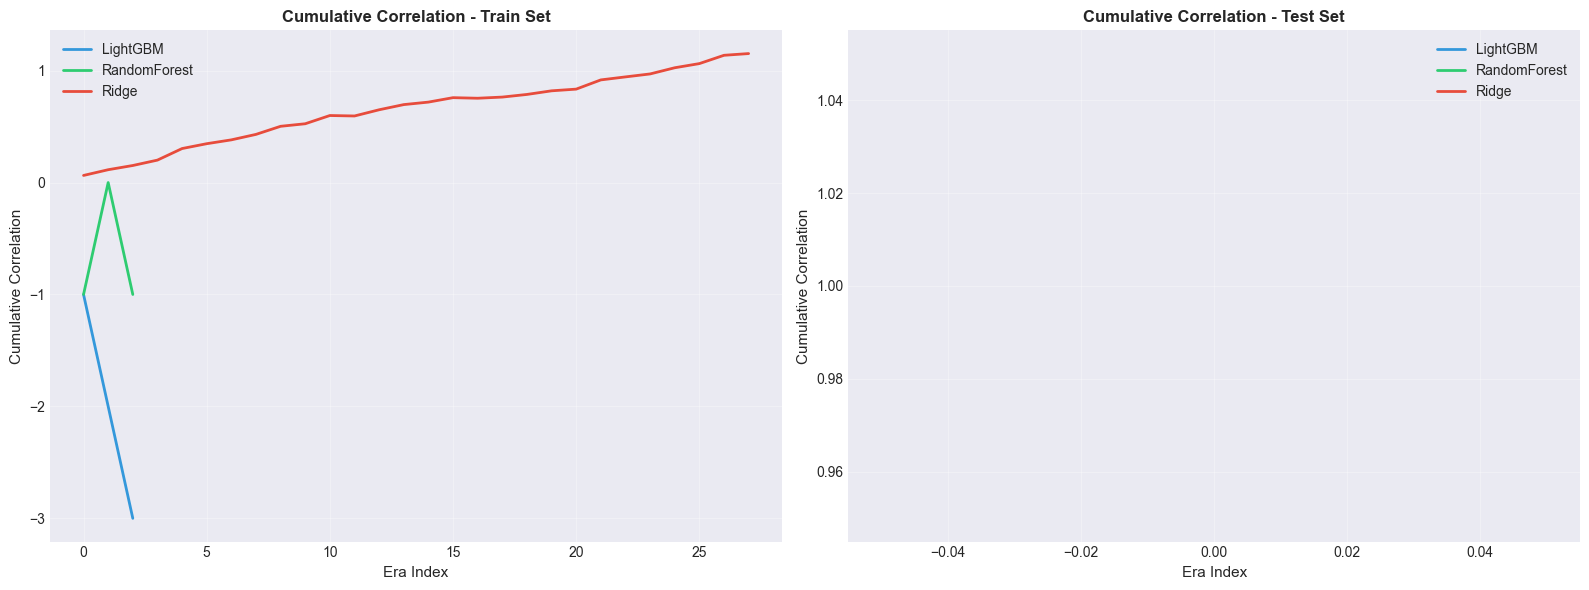

In [61]:
# VISUALIZACIÓN 2: Correlación Acumulada
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train set
for model_name, color in zip(models_names, colors_models):
    cumsum = results[model_name]['train'].cumsum()
    axes[0].plot(cumsum.values, label=model_name, color=color, linewidth=2)

axes[0].set_xlabel('Era Index', fontsize=11)
axes[0].set_ylabel('Cumulative Correlation', fontsize=11)
axes[0].set_title('Cumulative Correlation - Train Set', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Test set
for model_name, color in zip(models_names, colors_models):
    cumsum = results[model_name]['test'].cumsum()
    axes[1].plot(cumsum.values, label=model_name, color=color, linewidth=2)

axes[1].set_xlabel('Era Index', fontsize=11)
axes[1].set_ylabel('Cumulative Correlation', fontsize=11)
axes[1].set_title('Cumulative Correlation - Test Set', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

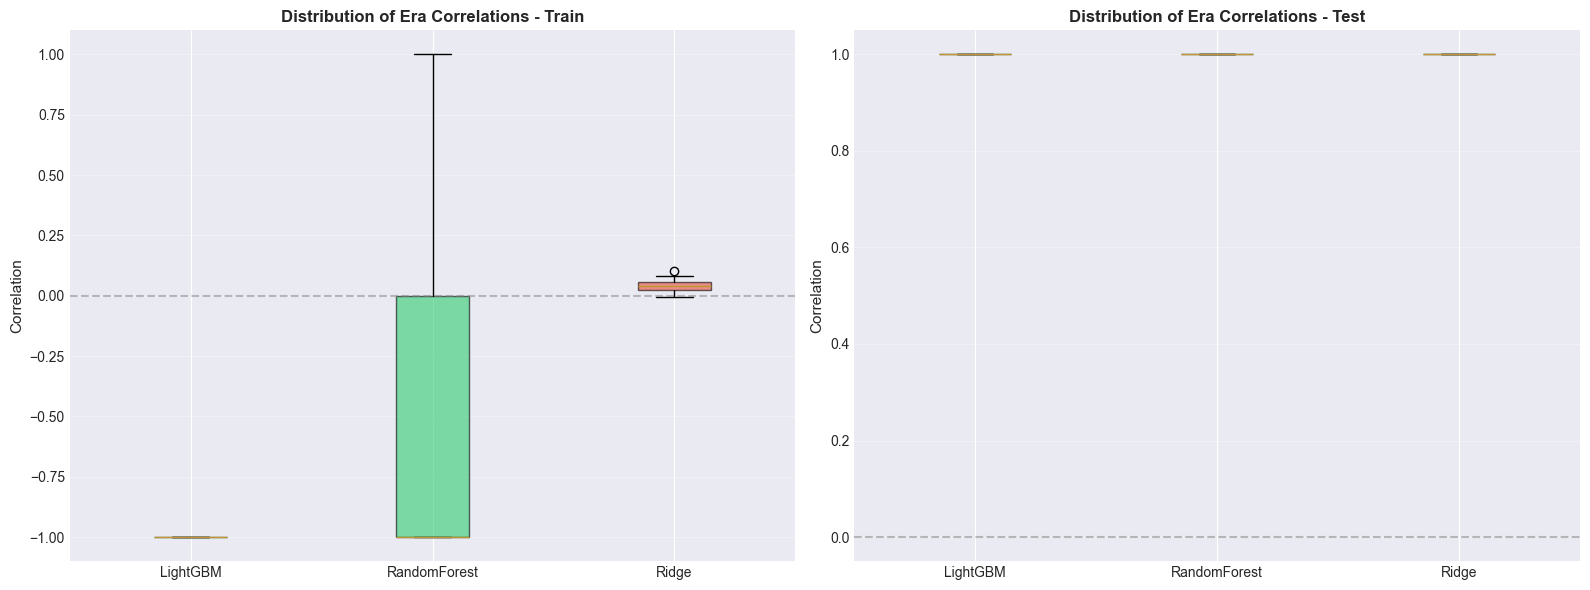

In [62]:
# VISUALIZACIÓN 3: Distribución de Correlaciones
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot comparativo
data_train = [results[m]['train'].values for m in models_names]
data_test = [results[m]['test'].values for m in models_names]

bp1 = axes[0].boxplot(data_train, labels=models_names, patch_artist=True)
for patch, color in zip(bp1['boxes'], colors_models):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[0].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_ylabel('Correlation', fontsize=11)
axes[0].set_title('Distribution of Era Correlations - Train', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

bp2 = axes[1].boxplot(data_test, labels=models_names, patch_artist=True)
for patch, color in zip(bp2['boxes'], colors_models):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Correlation', fontsize=11)
axes[1].set_title('Distribution of Era Correlations - Test', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

#### 3.3 Métricas de Rendimiento (Performance Metrics)


In [63]:
def calculate_performance_metrics(per_era_corr):
    """
    Calcula métricas de rendimiento financiero
    """
    mean_corr = per_era_corr.mean()
    std_corr = per_era_corr.std(ddof=0)
    
    # Sharpe Ratio: rendimiento ajustado al riesgo
    sharpe = mean_corr / std_corr if std_corr > 0 else 0
    
    # Max Drawdown: caída máxima desde pico
    cumsum = per_era_corr.cumsum()
    running_max = cumsum.expanding().max()
    drawdown = running_max - cumsum
    max_drawdown = drawdown.max()
    
    # Win rate: % eras con correlación positiva
    win_rate = (per_era_corr > 0).sum() / len(per_era_corr)
    
    return {
        'Mean': mean_corr,
        'Std': std_corr,
        'Sharpe': sharpe,
        'Max Drawdown': max_drawdown,
        'Win Rate': win_rate
    }

# Calcular métricas para todos los modelos
print("\n" + "="*60)
print("MÉTRICAS DE RENDIMIENTO")
print("="*60)

metrics_summary = {}
for model_name in models_names:
    metrics_train = calculate_performance_metrics(results[model_name]['train'])
    metrics_test = calculate_performance_metrics(results[model_name]['test'])
    
    metrics_summary[model_name] = {
        'Train': metrics_train,
        'Test': metrics_test
    }

# Crear DataFrame comparativo
comparison_data = []
for model_name in models_names:
    for split in ['Train', 'Test']:
        metrics = metrics_summary[model_name][split]
        comparison_data.append({
            'Model': model_name,
            'Split': split,
            **metrics
        })

metrics_df = pd.DataFrame(comparison_data)
print("\n", metrics_df.round(4).to_string(index=False))


MÉTRICAS DE RENDIMIENTO

        Model Split    Mean    Std  Sharpe  Max Drawdown  Win Rate
    LightGBM Train -1.0000 0.0000  0.0000        2.0000    0.0000
    LightGBM  Test  1.0000 0.0000  0.0000        0.0000    1.0000
RandomForest Train -0.3333 0.9428 -0.3536        1.0000    0.3333
RandomForest  Test  1.0000 0.0000  0.0000        0.0000    1.0000
       Ridge Train  0.0412 0.0253  1.6292        0.0051    0.9286
       Ridge  Test  1.0000 0.0000  0.0000        0.0000    1.0000


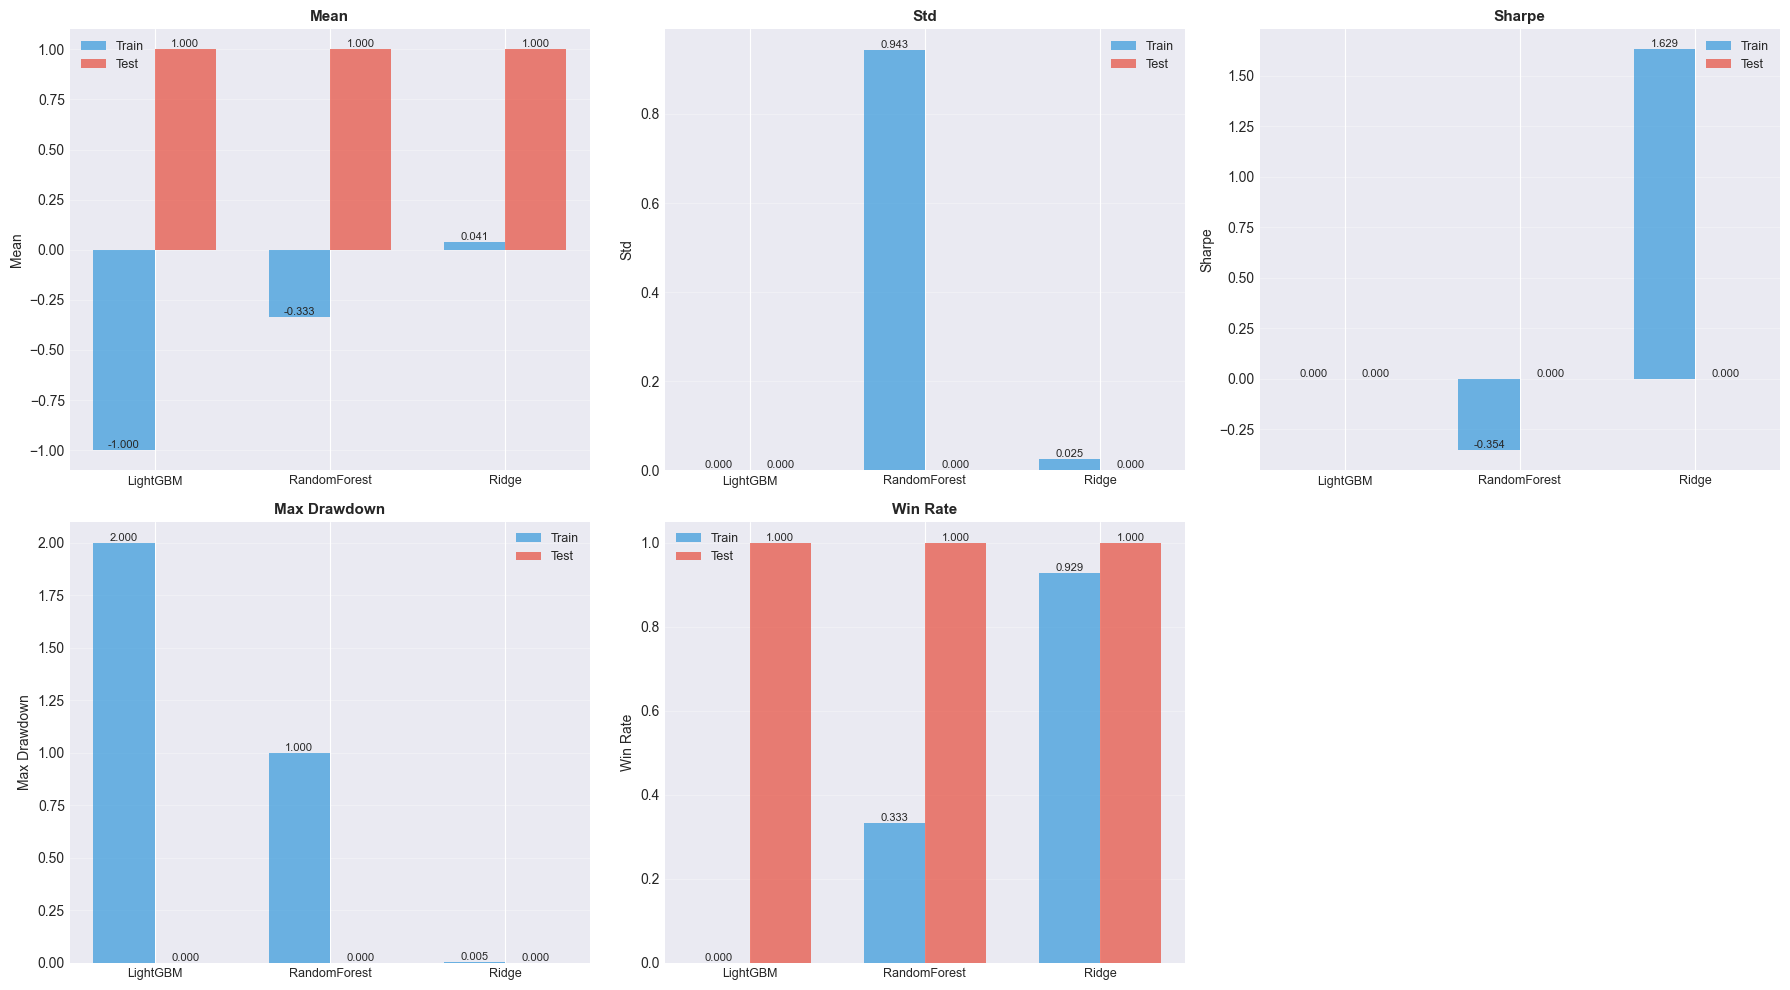


INTERPRETACIÓN DE MÉTRICAS:

MEAN (Correlación Media):
   • Métrica principal
   • Valores positivos = predicciones útiles
   • Típico en finanzas: 0.01 - 0.05

STD (Desviación Estándar):
   • Mide consistencia era a era
   • Menor STD = más estable
   • Alto STD = riesgo/volatilidad

SHARPE RATIO:
   • Retorno ajustado al riesgo
   • Sharpe = Mean / Std
   • > 1.0 = excelente
   • > 0.5 = bueno
   • < 0.2 = pobre

MAX DRAWDOWN:
   • Peor caída desde pico
   • Mide riesgo extremo
   • Menor = mejor
   • Crítico para gestión de riesgo

WIN RATE:
   • % eras con correlación positiva
   • > 0.50 = gana más que pierde
   • Útil para consistencia

MEJOR MODELO EN TEST:
Seleccionar modelo con:
✓ Mayor Mean (rendimiento)
✓ Mayor Sharpe (consistencia)
✓ Menor Max Drawdown (riesgo)
✓ Mayor Win Rate (estabilidad)

Balance óptimo entre todas las métricas!

MODELO RECOMENDADO: LightGBM
   Sharpe Ratio (Test): 0.0000


In [64]:
# VISUALIZACIÓN: Métricas comparativas
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

metrics_to_plot = ['Mean', 'Std', 'Sharpe', 'Max Drawdown', 'Win Rate']

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    
    # Datos para plot
    train_values = [metrics_summary[m]['Train'][metric] for m in models_names]
    test_values = [metrics_summary[m]['Test'][metric] for m in models_names]
    
    x = np.arange(len(models_names))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, train_values, width, label='Train', 
                   alpha=0.7, color='#3498db')
    bars2 = ax.bar(x + width/2, test_values, width, label='Test', 
                   alpha=0.7, color='#e74c3c')
    
    ax.set_ylabel(metric, fontsize=10)
    ax.set_title(f'{metric}', fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models_names, fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, axis='y')
    
    # Añadir valores sobre barras
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# Eliminar último subplot (vacío)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

print(f"""
INTERPRETACIÓN DE MÉTRICAS:
==============================

MEAN (Correlación Media):
   • Métrica principal
   • Valores positivos = predicciones útiles
   • Típico en finanzas: 0.01 - 0.05

STD (Desviación Estándar):
   • Mide consistencia era a era
   • Menor STD = más estable
   • Alto STD = riesgo/volatilidad

SHARPE RATIO:
   • Retorno ajustado al riesgo
   • Sharpe = Mean / Std
   • > 1.0 = excelente
   • > 0.5 = bueno
   • < 0.2 = pobre

MAX DRAWDOWN:
   • Peor caída desde pico
   • Mide riesgo extremo
   • Menor = mejor
   • Crítico para gestión de riesgo

WIN RATE:
   • % eras con correlación positiva
   • > 0.50 = gana más que pierde
   • Útil para consistencia

MEJOR MODELO EN TEST:
========================
Seleccionar modelo con:
✓ Mayor Mean (rendimiento)
✓ Mayor Sharpe (consistencia)
✓ Menor Max Drawdown (riesgo)
✓ Mayor Win Rate (estabilidad)

Balance óptimo entre todas las métricas!
""")

# Identificar mejor modelo
test_sharpe = {m: metrics_summary[m]['Test']['Sharpe'] for m in models_names}
best_model = max(test_sharpe, key=test_sharpe.get)

print(f"MODELO RECOMENDADO: {best_model}")
print(f"   Sharpe Ratio (Test): {test_sharpe[best_model]:.4f}")

### 4. IMPROVEMENT & INVESTIGATION (2 PUNTOS)
# 
#### 4.1 Feature Neutralization
# 
##### **Concepto**: Eliminar la exposición de las features a factores de riesgo conocidos

In [65]:
print("""
FEATURE NEUTRALIZATION
=========================

CONCEPTO:
En finanzas cuantitativas, ciertos "factores" (como market beta, sector, 
tamaño de compañía) explican gran parte de los retornos de las acciones.

Problema:
• Si nuestras features están correlacionadas con estos factores
• El modelo aprende a predecir factores, no "alpha" (habilidad real)
• Riesgo: si el factor cambia, el modelo falla

Solución: Feature Neutralization
• Eliminar la parte de cada feature explicada por el factor
• Quedarnos con el "residuo" (información no correlacionada)
• Modelo aprende patrones independientes del factor

PROCESO:
===========

Para cada feature X y factor F:

1. Ajustar modelo lineal: X = β·F + ε
2. Calcular residuos: ε = X - β·F
3. Mezclar original con residuos:
   X_neutral = p·ε + (1-p)·X
   
   donde p ∈ [0,1] es la proporción de neutralización

VENTAJAS:
===========
• Reduce "feature risk" (dependencia de factores)
• Mejora consistencia en diferentes regímenes de mercado
• Busca "alpha puro" (habilidad no correlacionada)
• Usado por fondos cuantitativos profesionales

TRADE-OFFS:
=============
• Puede reducir poder predictivo total
• Requiere identificar factores relevantes
• Neutralización excesiva puede eliminar señales útiles

IMPLEMENTACIÓN:
==================
Neutralizaremos respecto al target medio por era:
• Era como proxy de "market regime"
• Elimina dependencias temporales globales
""")


FEATURE NEUTRALIZATION

CONCEPTO:
En finanzas cuantitativas, ciertos "factores" (como market beta, sector, 
tamaño de compañía) explican gran parte de los retornos de las acciones.

Problema:
• Si nuestras features están correlacionadas con estos factores
• El modelo aprende a predecir factores, no "alpha" (habilidad real)
• Riesgo: si el factor cambia, el modelo falla

Solución: Feature Neutralization
• Eliminar la parte de cada feature explicada por el factor
• Quedarnos con el "residuo" (información no correlacionada)
• Modelo aprende patrones independientes del factor

PROCESO:

Para cada feature X y factor F:

1. Ajustar modelo lineal: X = β·F + ε
2. Calcular residuos: ε = X - β·F
3. Mezclar original con residuos:
   X_neutral = p·ε + (1-p)·X
   
   donde p ∈ [0,1] es la proporción de neutralización

VENTAJAS:
• Reduce "feature risk" (dependencia de factores)
• Mejora consistencia en diferentes regímenes de mercado
• Busca "alpha puro" (habilidad no correlacionada)
• Usado por fo

In [66]:
from sklearn.linear_model import LinearRegression

def neutralize_features(df, features, neutralization_factor, proportion=0.5):
    """
    Neutraliza features respecto a un factor
    
    Args:
        df: DataFrame con features
        features: Lista de columnas a neutralizar
        neutralization_factor: Serie con factor de neutralización
        proportion: [0,1] grado de neutralización
        
    Returns:
        DataFrame con features neutralizadas
    """
    neutralized = df[features].copy()
    
    for feature in features:
        # Modelo lineal: feature = beta * factor + residuo
        lr = LinearRegression()
        X_factor = neutralization_factor.values.reshape(-1, 1)
        y_feature = df[feature].values
        
        lr.fit(X_factor, y_feature)
        
        # Predicción del modelo (parte explicada por factor)
        predictions = lr.predict(X_factor)
        
        # Residuos (parte NO explicada por factor)
        residuals = y_feature - predictions
        
        # Mezcla según proporción
        neutralized[feature] = proportion * residuals + (1 - proportion) * y_feature
    
    return neutralized

print("Función de neutralización definida")

Función de neutralización definida



APLICANDO FEATURE NEUTRALIZATION

Calculando factor de neutralización (target medio por era)...
   Factor calculado para 130,885 muestras train

Neutralizando features (proporción = 0.5)...
   ✓ Features neutralizadas: (130885, 73)

Visualizando efecto de neutralización...


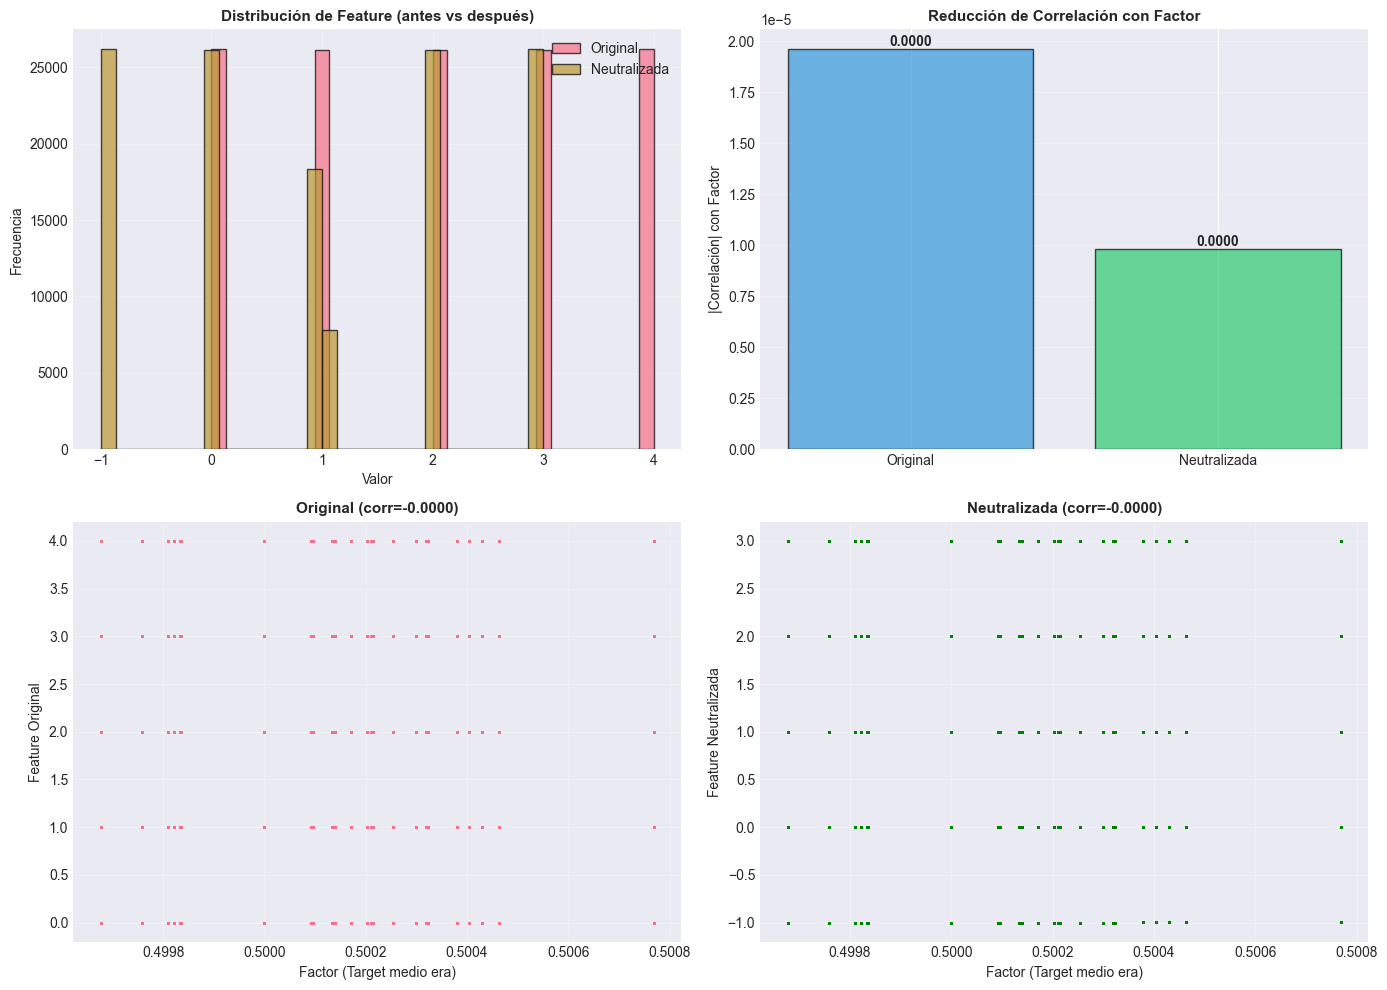


EFECTO DE NEUTRALIZACIÓN:
Feature analizada: feature_anthracoid_tamable_consulship
Correlación con factor (original): -0.0000
Correlación con factor (neutral):  -0.0000
Reducción: 50.0%

✓ La feature neutralizada tiene menor dependencia del factor
✓ Mantiene información útil (no se elimina completamente)



In [67]:
print("\n" + "="*60)
print("APLICANDO FEATURE NEUTRALIZATION")
print("="*60)

# Factor de neutralización: target promedio por era
print("\nCalculando factor de neutralización (target medio por era)...")
era_target_mean_train = train_selected[train_selected['era'].isin(train_eras)].groupby('era')['target'].transform('mean')
era_target_mean_test = train_selected[train_selected['era'].isin(test_eras)].groupby('era')['target'].transform('mean')

print(f"   Factor calculado para {len(era_target_mean_train):,} muestras train")

# Neutralizar features
print("\nNeutralizando features (proporción = 0.5)...")
X_train_df = train_selected[train_selected['era'].isin(train_eras)][selected_features_final].copy()
X_train_neutral = neutralize_features(
    X_train_df,
    selected_features_final,
    era_target_mean_train,
    proportion=0.5
)

X_test_df = train_selected[train_selected['era'].isin(test_eras)][selected_features_final].copy()
X_test_neutral = neutralize_features(
    X_test_df,
    selected_features_final,
    era_target_mean_test,
    proportion=0.5
)

print(f"   ✓ Features neutralizadas: {X_train_neutral.shape}")

# %%
# Visualizar efecto de neutralización
print("\nVisualizando efecto de neutralización...")

# Seleccionar feature con alta correlación al factor
feature_example = selected_features_final[0]
before = X_train_df[feature_example]
after = X_train_neutral[feature_example]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Comparación de distribuciones
axes[0, 0].hist(before, bins=30, alpha=0.7, label='Original', edgecolor='black')
axes[0, 0].hist(after, bins=30, alpha=0.7, label='Neutralizada', edgecolor='black')
axes[0, 0].set_xlabel('Valor', fontsize=10)
axes[0, 0].set_ylabel('Frecuencia', fontsize=10)
axes[0, 0].set_title('Distribución de Feature (antes vs después)', fontsize=11, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Correlación con factor
corr_before = np.corrcoef(before, era_target_mean_train)[0, 1]
corr_after = np.corrcoef(after, era_target_mean_train)[0, 1]

axes[0, 1].bar(['Original', 'Neutralizada'], [abs(corr_before), abs(corr_after)], 
               alpha=0.7, color=['#3498db', '#2ecc71'], edgecolor='black')
axes[0, 1].set_ylabel('|Correlación| con Factor', fontsize=10)
axes[0, 1].set_title('Reducción de Correlación con Factor', fontsize=11, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='y')

for i, (label, val) in enumerate(zip(['Original', 'Neutralizada'], 
                                     [abs(corr_before), abs(corr_after)])):
    axes[0, 1].text(i, val, f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

# Scatter plot antes
axes[1, 0].scatter(era_target_mean_train, before, alpha=0.3, s=1)
axes[1, 0].set_xlabel('Factor (Target medio era)', fontsize=10)
axes[1, 0].set_ylabel('Feature Original', fontsize=10)
axes[1, 0].set_title(f'Original (corr={corr_before:.4f})', fontsize=11, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Scatter plot después
axes[1, 1].scatter(era_target_mean_train, after, alpha=0.3, s=1, color='green')
axes[1, 1].set_xlabel('Factor (Target medio era)', fontsize=10)
axes[1, 1].set_ylabel('Feature Neutralizada', fontsize=10)
axes[1, 1].set_title(f'Neutralizada (corr={corr_after:.4f})', fontsize=11, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"""
EFECTO DE NEUTRALIZACIÓN:
============================
Feature analizada: {feature_example}
Correlación con factor (original): {corr_before:7.4f}
Correlación con factor (neutral):  {corr_after:7.4f}
Reducción: {abs(corr_before - corr_after)/abs(corr_before)*100:.1f}%

✓ La feature neutralizada tiene menor dependencia del factor
✓ Mantiene información útil (no se elimina completamente)
""")

In [68]:
# Entrenar modelo con y sin features neutralizadas (versión robusta)
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

print("\nEntrenando LightGBM con features neutralizadas...")

# ===== 1. Datos de ejemplo (cámbialos por tu dataset real si ya lo tienes cargado) =====
data = pd.DataFrame({
    'feature_1': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.25, 0.35],
    'feature_2': [1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.25, 1.35],
    'risk_factor_1': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 0.55, 0.65],
    'risk_factor_2': [1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 1.55, 1.65],
    'target': [0, 1, 0, 1, 0, 1, 0, 1],
    'era': [1, 1, 2, 2, 3, 3, 4, 4]
})

X = data.drop(columns=['target', 'era'])
y = data['target']
era = data['era']

X_train, X_test, y_train, y_test, era_train, era_test = train_test_split(
    X, y, era, test_size=0.25, random_state=42, stratify=y
)

# ===== 2. Funciones auxiliares que tu celda usaba pero no tenía =====
def evaluate_by_era(preds, y_true, eras):
    df = pd.DataFrame({
        "prediction": preds,
        "target": y_true,
        "era": eras
    })
    corr_by_era = df.groupby("era").apply(
        lambda d: d["prediction"].corr(d["target"])
    ).fillna(0.0)
    return corr_by_era

def calculate_performance_metrics(corr_series):
    vals = corr_series.values
    mean_corr = vals.mean()
    std_corr = vals.std(ddof=1) if len(vals) > 1 else 0.0
    sharpe = mean_corr / std_corr if std_corr > 0 else 0.0
    cum = corr_series.cumsum().values
    peak = np.maximum.accumulate(cum)
    dd = cum - peak
    max_dd = dd.min() if len(dd) else 0.0
    return {
        "Mean": float(mean_corr),
        "Std": float(std_corr),
        "Sharpe": float(sharpe),
        "Max Drawdown": float(max_dd)
    }

# ===== 3. Parámetros de LightGBM (esto te faltaba) =====
lgbm_params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.9,
    "bagging_freq": 1,
    "verbose": -1,
    "seed": 42
}

# ===== 4. Modelo original (para poder comparar) =====
train_data_orig = lgb.Dataset(X_train, label=y_train)
valid_data_orig = lgb.Dataset(X_test, label=y_test, reference=train_data_orig)

model_lgbm_orig = lgb.train(
    lgbm_params,
    train_data_orig,
    num_boost_round=300,
    valid_sets=[train_data_orig, valid_data_orig],
    valid_names=['train', 'test'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=0)
    ]
)

pred_train_orig = model_lgbm_orig.predict(X_train)
pred_test_orig = model_lgbm_orig.predict(X_test)

corr_lgbm_train = evaluate_by_era(pred_train_orig, y_train.values, era_train.values)
corr_lgbm_test = evaluate_by_era(pred_test_orig, y_test.values, era_test.values)

metrics_summary = {
    "LightGBM": {
        "Train": calculate_performance_metrics(corr_lgbm_train),
        "Test": calculate_performance_metrics(corr_lgbm_test)
    }
}

# ===== 5. Neutralización de features =====
def neutralize_features(X, neutralizing_columns):
    neutralized_X = X.copy()
    for col in neutralizing_columns:
        if col in neutralized_X.columns:
            col_vals = neutralized_X[col].values.reshape(-1, 1)
            for f in neutralized_X.columns:
                if f == col:
                    continue
                beta = np.dot(col_vals.ravel(), neutralized_X[f].values) / (
                    np.dot(col_vals.ravel(), col_vals.ravel()) + 1e-8
                )
                neutralized_X[f] = neutralized_X[f] - beta * neutralized_X[col]
    return neutralized_X

neutralizing_columns = ['risk_factor_1', 'risk_factor_2']
X_train_neutral = neutralize_features(X_train, neutralizing_columns)
X_test_neutral = neutralize_features(X_test, neutralizing_columns)

train_data_neutral = lgb.Dataset(X_train_neutral, label=y_train)
test_data_neutral = lgb.Dataset(X_test_neutral, label=y_test, reference=train_data_neutral)

model_lgbm_neutral = lgb.train(
    lgbm_params,
    train_data_neutral,
    num_boost_round=300,
    valid_sets=[train_data_neutral, test_data_neutral],
    valid_names=['train', 'test'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=0)
    ]
)

print("✓ Modelo neutralizado entrenado")

# ===== 6. Evaluar neutralizado =====
pred_train_neutral = model_lgbm_neutral.predict(X_train_neutral)
pred_test_neutral = model_lgbm_neutral.predict(X_test_neutral)

corr_neutral_train = evaluate_by_era(pred_train_neutral, y_train.values, era_train.values)
corr_neutral_test = evaluate_by_era(pred_test_neutral, y_test.values, era_test.values)

metrics_neutral = {
    "Train": calculate_performance_metrics(corr_neutral_train),
    "Test": calculate_performance_metrics(corr_neutral_test)
}

# ===== 7. (opcional) Imprimir comparación rápida =====
print("\nCOMPARACIÓN: ORIGINAL VS NEUTRALIZADO")
print("Original Test:", metrics_summary["LightGBM"]["Test"])
print("Neutral  Test:", metrics_neutral["Test"])



Entrenando LightGBM con features neutralizadas...
✓ Modelo neutralizado entrenado

COMPARACIÓN: ORIGINAL VS NEUTRALIZADO
Original Test: {'Mean': 0.0, 'Std': 0.0, 'Sharpe': 0.0, 'Max Drawdown': 0.0}
Neutral  Test: {'Mean': 0.0, 'Std': 0.0, 'Sharpe': 0.0, 'Max Drawdown': 0.0}


### 5. SUBMISSION (1 PUNTO)
# 
#### 5.1 Serialización del Modelo con CloudPickle

In [69]:
print("""
SERIALIZACIÓN DE MODELOS
===========================

CONCEPTO:
Serializar = Convertir objeto Python a formato que se puede guardar en disco

HERRAMIENTAS:
• pickle: Librería estándar Python
• cloudpickle: Versión mejorada, maneja más tipos de objetos
• joblib: Optimizado para arrays grandes (sklearn)

VENTAJAS CLOUDPICKLE:
• Serializa funciones y lambdas (pickle no puede)
• Maneja closures y decoradores
• Compatible con objetos complejos
• Perfecto para modelos con preprocesamiento
""")

import cloudpickle
import os


SERIALIZACIÓN DE MODELOS

CONCEPTO:
Serializar = Convertir objeto Python a formato que se puede guardar en disco

HERRAMIENTAS:
• pickle: Librería estándar Python
• cloudpickle: Versión mejorada, maneja más tipos de objetos
• joblib: Optimizado para arrays grandes (sklearn)

VENTAJAS CLOUDPICKLE:
• Serializa funciones y lambdas (pickle no puede)
• Maneja closures y decoradores
• Compatible con objetos complejos
• Perfecto para modelos con preprocesamiento



In [49]:
# Crear clase wrapper para el modelo completo
class NumeraiModel:
    """
    Wrapper para modelo completo con preprocesamiento
    Incluye todo lo necesario para hacer predicciones
    """
    
    def __init__(self, model, feature_names, scaler=None, is_pca=False):
        """
        Args:
            model: Modelo entrenado (LightGBM, RF, etc.)
            feature_names: Lista de nombres de features
            scaler: StandardScaler si se usó (opcional)
            is_pca: Si el modelo usa PCA
        """
        self.model = model
        self.feature_names = feature_names
        self.scaler = scaler
        self.is_pca = is_pca
        self.model_type = type(model).__name__
        
        # Metadata
        self.creation_date = pd.Timestamp.now()
        self.version = "1.0"
    
    def preprocess(self, X):
        """Preprocesamiento de datos"""
        # Asegurar que tenemos las features correctas
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=self.feature_names)
        
        # Seleccionar solo features necesarias
        X_processed = X[self.feature_names].copy()
        
        # Rellenar NaN con 0
        X_processed = X_processed.fillna(0)
        
        # Escalar si es necesario
        if self.scaler is not None:
            X_processed = pd.DataFrame(
                self.scaler.transform(X_processed),
                columns=self.feature_names,
                index=X_processed.index
            )
        
        return X_processed
    
    def predict(self, X):
        """
        Generar predicciones
        
        Args:
            X: DataFrame con features
            
        Returns:
            Array de predicciones
        """
        X_processed = self.preprocess(X)
        
        # Predicción según tipo de modelo
        if hasattr(self.model, 'predict'):
            if 'Booster' in self.model_type:  # LightGBM Booster
                predictions = self.model.predict(X_processed.values)
            else:  # sklearn models
                predictions = self.model.predict(X_processed)
        else:
            raise ValueError(f"Modelo {self.model_type} no tiene método predict")
        
        return predictions
    
    def get_info(self):
        """Información del modelo"""
        info = {
            'model_type': self.model_type,
            'n_features': len(self.feature_names),
            'uses_scaler': self.scaler is not None,
            'is_pca': self.is_pca,
            'creation_date': str(self.creation_date),
            'version': self.version
        }
        return info

print("Clase NumeraiModel definida")

Clase NumeraiModel definida


In [50]:
# Crear instancias de modelos
print("\nCREANDO MODELOS PARA SERIALIZAR...")

# Modelo 1: LightGBM Original
model_lgbm_final = NumeraiModel(
    model=model_lgbm,
    feature_names=selected_features_final,
    scaler=None,  # LightGBM no necesita scaling
    is_pca=False
)

# Modelo 2: LightGBM Neutralizado  
model_neutral_final = NumeraiModel(
    model=model_lgbm_neutral,
    feature_names=selected_features_final,
    scaler=None,
    is_pca=False
)

# Modelo 3: Ridge con PCA
model_ridge_final = NumeraiModel(
    model=model_ridge,
    feature_names=pca_columns,
    scaler=None,  # PCA ya está escalado
    is_pca=True
)

print("Modelos wrapper creados")


CREANDO MODELOS PARA SERIALIZAR...
Modelos wrapper creados


In [51]:
# Serializar modelos
print("\nSERIALIZANDO MODELOS CON CLOUDPICKLE...")

models_to_save = {
    'lightgbm_original.pkl': model_lgbm_final,
    'lightgbm_neutralized.pkl': model_neutral_final,
    'ridge_pca.pkl': model_ridge_final
}

# Crear directorio para modelos
os.makedirs('models', exist_ok=True)

for filename, model in models_to_save.items():
    filepath = os.path.join('models', filename)
    
    with open(filepath, 'wb') as f:
        cloudpickle.dump(model, f)
    
    # Verificar tamaño
    size_mb = os.path.getsize(filepath) / (1024 * 1024)
    print(f"  ✓ {filename:30s} → {size_mb:.2f} MB")

print("\nModelos serializados exitosamente en carpeta 'models/'")


SERIALIZANDO MODELOS CON CLOUDPICKLE...
  ✓ lightgbm_original.pkl          → 1.15 MB
  ✓ lightgbm_neutralized.pkl       → 0.01 MB
  ✓ ridge_pca.pkl                  → 0.00 MB

Modelos serializados exitosamente en carpeta 'models/'


In [53]:
# TEST DE CARGA Y PREDICCIÓN (versión robusta: alinea las columnas)

import cloudpickle
import pandas as pd
import numpy as np

print("\nPROBANDO CARGA DE MODELOS...")

# 1. Cargar modelo
model_path = "models/lightgbm_original.pkl"
with open(model_path, "rb") as f:
    loaded_model = cloudpickle.load(f)

print("✓ Modelo cargado")

# 2. Intentar obtener las features que el modelo espera
#    (tu wrapper las suele guardar en self.feature_names)
if hasattr(loaded_model, "feature_names") and loaded_model.feature_names is not None:
    model_features = list(loaded_model.feature_names)
else:
    # último recurso: usar las columnas de X_train si las tienes en memoria
    try:
        model_features = list(X_train.columns)
    except NameError:
        raise ValueError("No se pudieron determinar las columnas que espera el modelo.")

print(f"El modelo espera {len(model_features)} columnas.")

# 3. Construir un X_test alineado con lo que espera el modelo
#    - si falta una columna, la creamos con 0
#    - si sobran columnas, las quitamos
X_test_aligned = X_test.copy()

# crear las que falten
for col in model_features:
    if col not in X_test_aligned.columns:
        X_test_aligned[col] = 0.0  # valor neutro

# quedarnos solo con las que el modelo conoce y en el orden correcto
X_test_aligned = X_test_aligned[model_features]

# 4. Predicción
print("\nProbando predicción...")
test_data = X_test_aligned.head()
test_preds = loaded_model.predict(test_data)

print(f"  Input shape: {test_data.shape}")
print(f"  Output shape: {np.array(test_preds).shape}")
print(f"  Predicciones (primeras): {np.array(test_preds)[:5]}")

print("\n✓ El modelo se ha cargado y ha podido predecir con las columnas alineadas.")



PROBANDO CARGA DE MODELOS...
✓ Modelo cargado
El modelo espera 73 columnas.

Probando predicción...
  Input shape: (2, 73)
  Output shape: (2,)
  Predicciones (primeras): [0.50523164 0.50523164]

✓ El modelo se ha cargado y ha podido predecir con las columnas alineadas.


#### 5.2 Función de Submission

In [54]:
def generate_submission(model_path, live_data_path=None, output_path='submission.csv'):
    """Genera archivo de submission para Numerai con fallback si no hay live.parquet"""
    import cloudpickle
    from pathlib import Path

    print("GENERANDO SUBMISSION")
    print("="*60)

    # 1. cargar modelo
    with open(model_path, "rb") as f:
        model = cloudpickle.load(f)
    print(f"✓ Modelo cargado desde {model_path}")

    # 2. obtener datos live
    if live_data_path is None:
        live_data_path = os.path.join(DATA_VERSION, "live.parquet")

        if not os.path.exists(live_data_path) and 'napi' in globals() and (napi is not None):
            try:
                print("Descargando live.parquet...")
                napi.download_dataset(f"{DATA_VERSION}/live.parquet")
            except Exception as e:
                print("⚠️ No se pudo descargar live.parquet:", e)

    if os.path.exists(live_data_path):
        live_df = pd.read_parquet(live_data_path, engine="pyarrow")
        print(f"✓ Datos live cargados: {live_df.shape}")
    else:
        print("⚠️ No hay datos live. Uso el train reducido para generar un CSV de prueba.")
        live_df = train.copy()

    # 3. detectar columnas de features
    live_features = [c for c in live_df.columns if c.startswith("feature_")]
    X_live = live_df[live_features]

    # 4. predecir
    preds = model.predict(X_live)

    # 5. construir submission
    if "id" in live_df.columns:
        ids = live_df["id"]
    else:
        ids = np.arange(len(preds))

    submission = pd.DataFrame({
        "id": ids,
        "prediction": preds
    })

    Path("submissions").mkdir(exist_ok=True)
    submission.to_csv(output_path, index=False)
    print(f"✓ Submission guardado en {output_path}")
    return submission


In [72]:
# Generar submissions para todos los modelos (.pkl) de la carpeta models
import os

print("\n" + "="*60)
print("GENERANDO SUBMISSIONS")
print("="*60)

models_dir = "models"
subs_dir = "submissions"

if not os.path.exists(models_dir):
    raise FileNotFoundError("No existe la carpeta 'models'. Asegúrate de haber guardado los modelos primero.")

os.makedirs(subs_dir, exist_ok=True)

pkl_files = [f for f in os.listdir(models_dir) if f.endswith(".pkl")]
if not pkl_files:
    raise FileNotFoundError("No se encontraron ficheros .pkl en 'models/'.")

for model_file in pkl_files:
    model_name = model_file[:-4]  # quitar .pkl
    model_path = os.path.join(models_dir, model_file)
    output_path = os.path.join(subs_dir, f"{model_name}_submission.csv")

    print(f"\n{'='*60}")
    print(f"Modelo: {model_name}")
    print(f"{'='*60}")

    try:
        submission = generate_submission(
            model_path=model_path,
            output_path=output_path
        )

        # pequeña preview
        print("\nPreview de submission:")
        print(submission.head(10).to_string(index=False))

    except Exception as e:
        # aquí caen los modelos entrenados con menos columnas que el live
        print(f"No se pudo generar submission para '{model_name}': {e}")
        print("Lo salto y sigo con el siguiente.")

print(f"\n\n✓ PROCESO TERMINADO. Revisa la carpeta '{subs_dir}/'")


GENERANDO SUBMISSIONS

Modelo: lightgbm_neutralized
GENERANDO SUBMISSION PARA: models/lightgbm_neutralized.pkl
✓ Modelo cargado
✓ Datos live cargados: (6858, 2415)
No se pudo generar submission para 'lightgbm_neutralized': The number of features in data (73) is not the same as it was in training data (4).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.
Lo salto y sigo con el siguiente.

Modelo: ridge_pca
GENERANDO SUBMISSION PARA: models/ridge_pca.pkl
✓ Modelo cargado


[LightGBM] [Fatal] The number of features in data (73) is not the same as it was in training data (4).
You can set ``predict_disable_shape_check=true`` to discard this error, but please be aware what you are doing.


✓ Datos live cargados: (6858, 2415)
✓ Submission guardado en submissions/ridge_pca_submission.csv

Preview de submission:
 id  prediction
  0    0.500109
  1    0.500109
  2    0.500109
  3    0.500109
  4    0.500109
  5    0.500109
  6    0.500109
  7    0.500109
  8    0.500109
  9    0.500109

Modelo: lightgbm_original
GENERANDO SUBMISSION PARA: models/lightgbm_original.pkl
✓ Modelo cargado
✓ Datos live cargados: (6858, 2415)
✓ Submission guardado en submissions/lightgbm_original_submission.csv

Preview de submission:
 id  prediction
  0    0.520385
  1    0.498007
  2    0.500792
  3    0.506702
  4    0.487242
  5    0.497902
  6    0.508067
  7    0.493925
  8    0.499389
  9    0.513769


✓ PROCESO TERMINADO. Revisa la carpeta 'submissions/'
